In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import butter, filtfilt, find_peaks, hilbert
import warnings
import re

In [2]:
# ====== PARAMETRES ======
dossier = "Coda_data"

fichiers_S01 = [
    "Gr4_S04_S1_20250011_013.txt",
    "Gr4_S04_S1_20250011_014.txt",
    "Gr4_S04_S1_20250011_015.txt",
    "Gr4_S04_S2_20250011_016.txt",
    "Gr4_S04_S2_20250011_017.txt",
    "Gr4_S04_S2_20250011_018.txt",
    "Gr4_S04_S3_20250011_019.txt",
    "Gr4_S04_S3_20250011_020.txt",
    "Gr4_S04_S3_20250011_021.txt",
    "Gr4_S04_S4_20250011_022.txt",
    "Gr4_S04_S4_20250011_023.txt",
    "Gr4_S04_S4_20250011_024.txt",
]

# ====== FILTRE PASSE-BAS ======
fs = 200
fc = 5
b, a = butter(4, fc/(fs/2), btype='low')
h = 1/fs  # pas de temps = 0.005 s

# ====== DATAFRAME FINAL ======
resultats = []

# ====== DATAFRAME POUR ANGLE ======
resultats_angle = []

for f in fichiers_S01:
    chemin = os.path.join(dossier, f)

    df = pd.read_csv(chemin, sep="\t", header=2)
    df.columns = df.columns.str.strip()
    df = df.replace("NaN", np.nan)

    colonnes_a_supprimer = [c for c in df.columns if ".V" in c or c.strip() == ""]
    df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

    time_col = "Time" if "Time" in df.columns else "Time (s)"

    pattern = r"Marker (1[7-9]|20)\.[XYZ]"
    
    colonnes_markers = [c for c in df.columns if re.search(pattern, c)]
    df = df[[time_col] + colonnes_markers]
    df = df.apply(pd.to_numeric, errors="coerce")

    # ====== CENTRE RECTANGLE ======
    cx = ((df["Marker 17.X"] + df["Marker 18.X"])/2 +
          (df["Marker 19.X"] + df["Marker 20.X"])/2)/2

    cy = ((df["Marker 17.Y"] + df["Marker 18.Y"])/2 +
          (df["Marker 19.Y"] + df["Marker 20.Y"])/2)/2

    cz = ((df["Marker 17.Z"] + df["Marker 18.Z"])/2 +
          (df["Marker 19.Z"] + df["Marker 20.Z"])/2)/2

    # ====== MILIEU MARKERS 5-6 ======
    top_x = (df["Marker 17.X"] + df["Marker 18.X"]) / 2
    top_z = (df["Marker 17.Y"] + df["Marker 18.Y"]) / 2

    # ====== INTERPOLATION NaN ======
    for signal in [cx, cy, cz, top_x, top_z]:
        nan_idx = np.isnan(signal)
        if np.any(nan_idx):
            signal[nan_idx] = np.interp(
                np.flatnonzero(nan_idx),
                np.flatnonzero(~nan_idx),
                signal[~nan_idx]
            )

    # ====== FILTRAGE ======
    cx = filtfilt(b, a, cx)
    cy = filtfilt(b, a, cy)
    cz = filtfilt(b, a, cz)

    top_x = filtfilt(b, a, top_x)
    top_z = filtfilt(b, a, top_z)

    # ====== NOM PROPRE ======
    m = re.search(r"Gr4_(S\d+)_(S\d+)_\d+_(\d+)\.txt$", f)
    if m:
        s_part = m.group(1)
        l_part = m.group(2)
        num = str(int(m.group(3)))
        col_base = f"{s_part}_{l_part}_{num}"
    else:
        col_base = f.replace(".txt","")

    # ====== DATAFRAME POSITION (comme avant) ======
    df_res = pd.DataFrame({
        "Time": df[time_col],
        f"{col_base}_X": cx,
        f"{col_base}_Y": cy,
        f"{col_base}_Z": cz
    })

    resultats.append(df_res)

    # ====== DATAFRAME POUR ANGLE ======
    df_angle = pd.DataFrame({
        "Time": df[time_col],
        f"{col_base}_center_X": cx,
        f"{col_base}_center_Y": cy,
        f"{col_base}_top_X": top_x,
        f"{col_base}_top_Z": top_z
    })

    resultats_angle.append(df_angle)


# ====== FUSION DATAFRAME POSITION ======
df_final = resultats[0]
for df in resultats[1:]:
    df_final = df_final.merge(df, on="Time")

# ====== FUSION DATAFRAME ANGLE ======
df_angle_base = resultats_angle[0]
for df in resultats_angle[1:]:
    df_angle_base = df_angle_base.merge(df, on="Time")

# ====== AFFICHAGE ======
print("✅ Fusion terminée")

print("\nColonnes df_final :")
print(df_final.columns.tolist())

print("\nColonnes df_angle_base :")
print(df_angle_base.columns.tolist())

✅ Fusion terminée

Colonnes df_final :
['Time', 'S04_S1_13_X', 'S04_S1_13_Y', 'S04_S1_13_Z', 'S04_S1_14_X', 'S04_S1_14_Y', 'S04_S1_14_Z', 'S04_S1_15_X', 'S04_S1_15_Y', 'S04_S1_15_Z', 'S04_S2_16_X', 'S04_S2_16_Y', 'S04_S2_16_Z', 'S04_S2_17_X', 'S04_S2_17_Y', 'S04_S2_17_Z', 'S04_S2_18_X', 'S04_S2_18_Y', 'S04_S2_18_Z', 'S04_S3_19_X', 'S04_S3_19_Y', 'S04_S3_19_Z', 'S04_S3_20_X', 'S04_S3_20_Y', 'S04_S3_20_Z', 'S04_S3_21_X', 'S04_S3_21_Y', 'S04_S3_21_Z', 'S04_S4_22_X', 'S04_S4_22_Y', 'S04_S4_22_Z', 'S04_S4_23_X', 'S04_S4_23_Y', 'S04_S4_23_Z', 'S04_S4_24_X', 'S04_S4_24_Y', 'S04_S4_24_Z']

Colonnes df_angle_base :
['Time', 'S04_S1_13_center_X', 'S04_S1_13_center_Y', 'S04_S1_13_top_X', 'S04_S1_13_top_Z', 'S04_S1_14_center_X', 'S04_S1_14_center_Y', 'S04_S1_14_top_X', 'S04_S1_14_top_Z', 'S04_S1_15_center_X', 'S04_S1_15_center_Y', 'S04_S1_15_top_X', 'S04_S1_15_top_Z', 'S04_S2_16_center_X', 'S04_S2_16_center_Y', 'S04_S2_16_top_X', 'S04_S2_16_top_Z', 'S04_S2_17_center_X', 'S04_S2_17_center_Y', 'S04_

In [3]:
# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_plots = os.path.join(dossier_root, "position_S04_filtre")
os.makedirs(dossier_plots, exist_ok=True)

time_col = "Time"
cols = [c for c in df_final.columns if c != time_col]

# ====== PLOTS ======
for col in cols:

    plt.figure(figsize=(8,3))

    plt.plot(df_final[time_col], df_final[col])

    plt.xlabel("Temps (s)")
    plt.ylabel(col)
    plt.title(f"{col} filtré (<{fc} Hz)")

    ticks = np.arange(
        0,
        float(df_final[time_col].iloc[-1]) + 1,
        5
    )
    plt.xticks(ticks)

    plt.tight_layout()

    # sauvegarde
    nom_fichier = f"{col}.png"
    chemin_plot = os.path.join(dossier_plots, nom_fichier)

    plt.savefig(chemin_plot, dpi=150)
    plt.close()

print(f"✅ Plots sauvegardés dans : {dossier_plots}")

✅ Plots sauvegardés dans : Cinematique_S04_S\position_S04_filtre


In [4]:
# ====== FONCTION VITESSE CENTREE ======
def vitesse_centre(U, h):
    """
    Dérivée centrée d'ordre 4 :
    u'[i] = (-U[i+2] + 8*U[i+1] - 8*U[i-1] + U[i-2]) / (12*h)
    """
    U = np.array(U, dtype=float)
    N = len(U)
    V = np.zeros_like(U)

    # début
    V[0] = (U[1] - U[0]) / h
    V[1] = (U[2] - U[1]) / h

    # points centraux
    for i in range(2, N-2):
        V[i] = (-U[i+2] + 8*U[i+1] - 8*U[i-1] + U[i-2]) / (12*h)

    # fin
    V[-2] = (U[-2] - U[-3]) / h
    V[-1] = (U[-1] - U[-2]) / h

    return V


# ====== CALCUL DES VITESSES ======

velocities = pd.DataFrame()

time_col = "Time"
velocities[time_col] = df_final[time_col]

cols = [c for c in df_final.columns if c != time_col]

for col in cols:

    velocities[col] = vitesse_centre(
        df_final[col].values,
        h
    )

print("✅ Calcul des vitesses terminé")

print("\nColonnes vitesses :")
print(velocities.columns.tolist())

✅ Calcul des vitesses terminé

Colonnes vitesses :
['Time', 'S04_S1_13_X', 'S04_S1_13_Y', 'S04_S1_13_Z', 'S04_S1_14_X', 'S04_S1_14_Y', 'S04_S1_14_Z', 'S04_S1_15_X', 'S04_S1_15_Y', 'S04_S1_15_Z', 'S04_S2_16_X', 'S04_S2_16_Y', 'S04_S2_16_Z', 'S04_S2_17_X', 'S04_S2_17_Y', 'S04_S2_17_Z', 'S04_S2_18_X', 'S04_S2_18_Y', 'S04_S2_18_Z', 'S04_S3_19_X', 'S04_S3_19_Y', 'S04_S3_19_Z', 'S04_S3_20_X', 'S04_S3_20_Y', 'S04_S3_20_Z', 'S04_S3_21_X', 'S04_S3_21_Y', 'S04_S3_21_Z', 'S04_S4_22_X', 'S04_S4_22_Y', 'S04_S4_22_Z', 'S04_S4_23_X', 'S04_S4_23_Y', 'S04_S4_23_Z', 'S04_S4_24_X', 'S04_S4_24_Y', 'S04_S4_24_Z']


In [5]:
# ===== TEMPS A OBSERVER ========
t_min = 7
t_max = 39

# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_plots_vitesse = os.path.join(dossier_root, "vitesse_S04")
os.makedirs(dossier_plots_vitesse, exist_ok=True)

# ====== PLOT DES VITESSES (+timing) ======
mask = (velocities[time_col] >= t_min) & (velocities[time_col] <= t_max)

for col in cols:
    plt.figure(figsize=(8,3))
    plt.plot(velocities[time_col][mask], velocities[col][mask], color='blue')
    plt.xlabel("Temps (s)")
    plt.ylabel(f"Vitesse de {col}")
    plt.title(f"Vitesse centrée filtrée (<{fc} Hz) de {col} ({t_min}–{t_max} s)")
    plt.grid(True)
    plt.tight_layout()

    # sauvegarde
    nom_fichier = f"vitesse_{col.replace(' ', '_')}.png"
    chemin_plot = os.path.join(dossier_plots_vitesse, nom_fichier)
    plt.savefig(chemin_plot, dpi=150)
    plt.close()

print(f"✅ Plot terminé et sauvegardé dans \"{dossier_plots_vitesse}\"")

✅ Plot terminé et sauvegardé dans "Cinematique_S04_S\vitesse_S04"


In [6]:
# ===== TEMPS A OBSERVER ========
t_min = 7
t_max = 39


# ===== PARAMETRES ==========
distance_pts = 200
prominence_pts = 5

time_col = "Time"
cols = [c for c in df_final.columns if c != time_col]

# ====== SELECTION INTERVALLE TEMPS ======
mask = (df_final[time_col] >= t_min) & (df_final[time_col] <= t_max)
time_segment = df_final[time_col][mask]

# ====== STOCKAGE ======
all_min_times = {}
all_max_times = {}

for col in cols:

    signal = df_final[col][mask].values
    time_vals = time_segment.values

    # ====== DETECTION MINIMA ======
    peaks_min, _ = find_peaks(
        -signal,
        distance=distance_pts,
        prominence=prominence_pts
    )

    minima_times = list(time_vals[peaks_min])

    # enlever premier et dernier
    if len(minima_times) > 2:
        minima_times = minima_times[1:-1]

    all_min_times[col] = minima_times


    # ====== DETECTION MAXIMA ======
    peaks_max, _ = find_peaks(
        signal,
        distance=distance_pts,
        prominence=prominence_pts
    )

    maxima_times = list(time_vals[peaks_max])

    # enlever premier et dernier
    if len(maxima_times) > 2:
        maxima_times = maxima_times[1:-1]

    all_max_times[col] = maxima_times


    # ====== PRINT INFO ======
    print(f"\n📊 {col}")
    print(f"Minima détectés (après suppression bords) : {len(minima_times)}")
    print(f"Maxima détectés (après suppression bords) : {len(maxima_times)}")


# ====== DATAFRAME MINIMA ======
max_len_min = max(len(v) for v in all_min_times.values())

minima_times_df = pd.DataFrame({
    col: pd.Series(v + [np.nan]*(max_len_min - len(v)))
    for col, v in all_min_times.items()
})


# ====== DATAFRAME MAXIMA ======
max_len_max = max(len(v) for v in all_max_times.values())

maxima_times_df = pd.DataFrame({
    col: pd.Series(v + [np.nan]*(max_len_max - len(v)))
    for col, v in all_max_times.items()
})


print(f"\n✅ DataFrame des minima : {minima_times_df.shape[0]} x {minima_times_df.shape[1]}")
print(f"✅ DataFrame des maxima : {maxima_times_df.shape[0]} x {maxima_times_df.shape[1]}")


📊 S04_S1_13_X
Minima détectés (après suppression bords) : 13
Maxima détectés (après suppression bords) : 14

📊 S04_S1_13_Y
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 15

📊 S04_S1_13_Z
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 13

📊 S04_S1_14_X
Minima détectés (après suppression bords) : 13
Maxima détectés (après suppression bords) : 14

📊 S04_S1_14_Y
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 14

📊 S04_S1_14_Z
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 14

📊 S04_S1_15_X
Minima détectés (après suppression bords) : 17
Maxima détectés (après suppression bords) : 14

📊 S04_S1_15_Y
Minima détectés (après suppression bords) : 16
Maxima détectés (après suppression bords) : 14

📊 S04_S1_15_Z
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 13

📊 S04_S2_16_X
Mini

In [7]:
# ===== TEMPS A OBSERVER ========
t_min = 7
t_max = 39

# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_plots_vitesse = os.path.join(dossier_root, "vitesse_S04_extrema")
os.makedirs(dossier_plots_vitesse, exist_ok=True)

# ====== PARAMETRES ======
time_col = "Time"
cols = [c for c in velocities.columns if c != time_col]

print(f"Velocities DataFrame : {velocities.shape[0]} lignes x {velocities.shape[1]} colonnes")
print(f"Minima Times DataFrame : {minima_times_df.shape[0]} lignes x {minima_times_df.shape[1]} colonnes")
print(f"Maxima Times DataFrame : {maxima_times_df.shape[0]} lignes x {maxima_times_df.shape[1]} colonnes\n")


for col in cols:

    # ====== SELECTION DE L'INTERVALLE ======
    mask = (velocities[time_col] >= t_min) & (velocities[time_col] <= t_max)

    time_vals = velocities[time_col][mask].values
    signal = velocities[col][mask].values

    plt.figure(figsize=(8,3))
    plt.plot(time_vals, signal, color='blue', label="Vitesse")


    # ====== MINIMA ======
    if col in minima_times_df.columns:

        peak_times = minima_times_df[col].dropna().values
        peak_times = peak_times[(peak_times >= t_min) & (peak_times <= t_max)]

        if len(peak_times) > 0:

            peak_indices = []
            for t in peak_times:
                idx = np.argmin(np.abs(time_vals - t))
                peak_indices.append(idx)

            peak_values = signal[peak_indices]

            plt.scatter(time_vals[peak_indices], peak_values,
                        color='red', s=30, label="Minima")


    # ====== MAXIMA ======
    if col in maxima_times_df.columns:

        peak_times = maxima_times_df[col].dropna().values
        peak_times = peak_times[(peak_times >= t_min) & (peak_times <= t_max)]

        if len(peak_times) > 0:

            peak_indices = []
            for t in peak_times:
                idx = np.argmin(np.abs(time_vals - t))
                peak_indices.append(idx)

            peak_values = signal[peak_indices]

            plt.scatter(time_vals[peak_indices], peak_values,
                        color='green', s=30, label="Maxima")


    # ====== FIGURE ======
    plt.xlabel("Temps (s)")
    plt.ylabel(f"Vitesse {col}")
    plt.title(f"Vitesse filtrée (<{fc} Hz) de {col} ({t_min}-{t_max}s)")
    plt.grid(True)
    plt.legend()
    plt.xlim(t_min, t_max)
    plt.tight_layout()


    # ====== SAUVEGARDE ======
    nom_fichier = f"vitesse_{col}.png"
    chemin_plot = os.path.join(dossier_plots_vitesse, nom_fichier)

    plt.savefig(chemin_plot, dpi=150)
    plt.close()


print(f"\n✅ Plots vitesse sauvegardés dans : {dossier_plots_vitesse}")

Velocities DataFrame : 8201 lignes x 37 colonnes
Minima Times DataFrame : 17 lignes x 36 colonnes
Maxima Times DataFrame : 15 lignes x 36 colonnes


✅ Plots vitesse sauvegardés dans : Cinematique_S04_S\vitesse_S04_extrema


In [8]:
# ====== PARAMETRES ======
time_col = "Time"
cols = [c for c in df_final.columns if c != time_col]

# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_plots_superp = os.path.join(dossier_root, "superp_S04")
os.makedirs(dossier_plots_superp, exist_ok=True)

cmap = plt.cm.viridis

# ====== SUPERPOSITION DES CYCLES ======
for col in cols:

    if col not in minima_times_df.columns:
        continue

    minima_times = minima_times_df[col].dropna().values

    if len(minima_times) < 2:
        continue

    fig, ax = plt.subplots(figsize=(8,4))

    n_cycles = len(minima_times) - 1

    for i in range(n_cycles):

        t_start = minima_times[i]
        t_end = minima_times[i+1]

        mask = (df_final[time_col] >= t_start) & (df_final[time_col] <= t_end)

        segment_time = df_final[time_col][mask].values - t_start
        segment_signal = df_final[col][mask].values

        if len(segment_time) == 0:
            continue

        color = cmap(i / n_cycles)

        ax.plot(segment_time, segment_signal, color=color)

    ax.set_xlabel("Temps depuis minima (s)")
    ax.set_ylabel(col)
    ax.set_title(f"Superposition des cycles : {col}")
    ax.grid(True)

    # ====== COLORBAR ======
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=n_cycles))
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Numéro du cycle\n(premiers → derniers)")

    fig.tight_layout()

    # ====== SAUVEGARDE ======
    nom_fichier = f"superp_{col}.png"
    chemin_plot = os.path.join(dossier_plots_superp, nom_fichier)

    fig.savefig(chemin_plot, dpi=150)
    plt.close(fig)

print(f"\n✅ Graphiques sauvegardés dans : {dossier_plots_superp}")


✅ Graphiques sauvegardés dans : Cinematique_S04_S\superp_S04


In [9]:
# ====== PARAMETRES ======
time_col = "Time"
cols = [c for c in velocities.columns if c != time_col]

# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_plots_superv = os.path.join(dossier_root, "superv_S04")
os.makedirs(dossier_plots_superv, exist_ok=True)

cmap = plt.cm.viridis

# ====== SUPERPOSITION DES VITESSES PAR CYCLE ======
for col in cols:

    if col not in minima_times_df.columns:
        continue

    minima_times = minima_times_df[col].dropna().values

    if len(minima_times) < 2:
        continue

    fig, ax = plt.subplots(figsize=(8,4))

    n_cycles = len(minima_times) - 1

    for i in range(n_cycles):

        t_start = minima_times[i]
        t_end = minima_times[i+1]

        # intervalle du cycle
        mask = (velocities[time_col] >= t_start) & (velocities[time_col] <= t_end)

        segment_time = velocities[time_col][mask].values - t_start
        segment_signal = velocities[col][mask].values

        if len(segment_time) == 0:
            continue

        color = cmap(i / n_cycles)

        ax.plot(segment_time, segment_signal, color=color)

    ax.set_xlabel("Temps depuis minima (s)")
    ax.set_ylabel(f"Vitesse {col}")
    ax.set_title(f"Superposition des vitesses : {col}")

    ax.grid(True)

    # ====== COLORBAR ======
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=n_cycles))
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Numéro du cycle\n(premiers → derniers)")

    fig.tight_layout()

    # ====== SAUVEGARDE ======
    nom_fichier = f"superv_{col}.png"
    chemin_plot = os.path.join(dossier_plots_superv, nom_fichier)

    fig.savefig(chemin_plot, dpi=150)
    plt.close(fig)

print(f"\n✅ Graphiques de vitesses sauvegardés dans : {dossier_plots_superv}")


✅ Graphiques de vitesses sauvegardés dans : Cinematique_S04_S\superv_S04


In [10]:
# ====== PARAMETRES ======
time_col = "Time"
cols = [c for c in df_final.columns if c != time_col]

# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_plots_sep = os.path.join(dossier_root, "superp_sep_S04")
os.makedirs(dossier_plots_sep, exist_ok=True)

cmap = plt.cm.viridis

# ====== SUPERPOSITION ASCENDANT / DESCENDANT ======
for col in cols:

    if col not in minima_times_df.columns or col not in maxima_times_df.columns:
        continue

    minima_times = minima_times_df[col].dropna().values
    maxima_times = maxima_times_df[col].dropna().values

    if len(minima_times) < 1 or len(maxima_times) < 1:
        continue

    # ====== FIGURES ======
    fig_up, ax_up = plt.subplots(figsize=(8,4))
    fig_down, ax_down = plt.subplots(figsize=(8,4))

    cycles_up = []
    cycles_down = []

    # ====== ASSOCIATION MIN/MAX ======
    for t_min in minima_times:

        max_after = maxima_times[maxima_times > t_min]
        if len(max_after) == 0:
            continue

        t_max = max_after[0]

        cycles_up.append((t_min, t_max))

    for t_max in maxima_times:

        min_after = minima_times[minima_times > t_max]
        if len(min_after) == 0:
            continue

        t_min = min_after[0]

        cycles_down.append((t_max, t_min))


    # ====== PHASE ASCENDANTE ======
    n_up = len(cycles_up)

    for i, (t_start, t_end) in enumerate(cycles_up):

        mask = (df_final[time_col] >= t_start) & (df_final[time_col] <= t_end)

        segment_time = df_final[time_col][mask].values - t_start
        segment_signal = df_final[col][mask].values

        if len(segment_time) == 0:
            continue

        color = cmap(i / n_up)

        ax_up.plot(segment_time, segment_signal, color=color)


    # ====== PHASE DESCENDANTE ======
    n_down = len(cycles_down)

    for i, (t_start, t_end) in enumerate(cycles_down):

        mask = (df_final[time_col] >= t_start) & (df_final[time_col] <= t_end)

        segment_time = df_final[time_col][mask].values - t_start
        segment_signal = df_final[col][mask].values

        if len(segment_time) == 0:
            continue

        color = cmap(i / n_down)

        ax_down.plot(segment_time, segment_signal, color=color)


    # ====== STYLE ======
    ax_up.set_xlabel("Temps depuis minima (s)")
    ax_up.set_ylabel(col)
    ax_up.set_title(f"Phases ascendantes : {col}")
    ax_up.grid(True)

    ax_down.set_xlabel("Temps depuis maxima (s)")
    ax_down.set_ylabel(col)
    ax_down.set_title(f"Phases descendantes : {col}")
    ax_down.grid(True)


    # ====== COLORBARS ======
    sm_up = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max(1,n_up)))
    sm_up.set_array([])
    fig_up.colorbar(sm_up, ax=ax_up).set_label("Numéro cycle")

    sm_down = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max(1,n_down)))
    sm_down.set_array([])
    fig_down.colorbar(sm_down, ax=ax_down).set_label("Numéro cycle")

    fig_up.tight_layout()
    fig_down.tight_layout()

    # ====== SAUVEGARDE ======
    fig_up.savefig(os.path.join(dossier_plots_sep, f"asc_{col}.png"), dpi=150)
    fig_down.savefig(os.path.join(dossier_plots_sep, f"desc_{col}.png"), dpi=150)

    plt.close(fig_up)
    plt.close(fig_down)

print(f"\n✅ Graphiques sauvegardés dans : {dossier_plots_sep}")


✅ Graphiques sauvegardés dans : Cinematique_S04_S\superp_sep_S04


In [11]:
# ====== PARAMETRES ======
time_col = "Time"
cols = [c for c in velocities.columns if c != time_col]

# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_plots_sep = os.path.join(dossier_root, "superv_sep_S04")
os.makedirs(dossier_plots_sep, exist_ok=True)

cmap = plt.cm.viridis

# ====== SUPERPOSITION ASCENDANT / DESCENDANT ======
for col in cols:

    if col not in minima_times_df.columns or col not in maxima_times_df.columns:
        continue

    minima_times = minima_times_df[col].dropna().values
    maxima_times = maxima_times_df[col].dropna().values

    if len(minima_times) < 1 or len(maxima_times) < 1:
        continue

    fig_up, ax_up = plt.subplots(figsize=(8,4))
    fig_down, ax_down = plt.subplots(figsize=(8,4))

    cycles_up = []
    cycles_down = []

    # ====== ASSOCIER MIN -> MAX ======
    for t_min in minima_times:

        max_after = maxima_times[maxima_times > t_min]
        if len(max_after) == 0:
            continue

        t_max = max_after[0]
        cycles_up.append((t_min, t_max))

    # ====== ASSOCIER MAX -> MIN ======
    for t_max in maxima_times:

        min_after = minima_times[minima_times > t_max]
        if len(min_after) == 0:
            continue

        t_min = min_after[0]
        cycles_down.append((t_max, t_min))


    # ====== PHASE ASCENDANTE ======
    n_up = len(cycles_up)

    for i, (t_start, t_end) in enumerate(cycles_up):

        mask = (velocities[time_col] >= t_start) & (velocities[time_col] <= t_end)

        segment_time = velocities[time_col][mask].values - t_start
        segment_signal = velocities[col][mask].values

        if len(segment_time) == 0:
            continue

        color = cmap(i / max(1, n_up))
        ax_up.plot(segment_time, segment_signal, color=color)


    # ====== PHASE DESCENDANTE ======
    n_down = len(cycles_down)

    for i, (t_start, t_end) in enumerate(cycles_down):

        mask = (velocities[time_col] >= t_start) & (velocities[time_col] <= t_end)

        segment_time = velocities[time_col][mask].values - t_start
        segment_signal = velocities[col][mask].values

        if len(segment_time) == 0:
            continue

        color = cmap(i / max(1, n_down))
        ax_down.plot(segment_time, segment_signal, color=color)


    # ====== STYLE ======
    ax_up.set_xlabel("Temps depuis minima (s)")
    ax_up.set_ylabel(f"Vitesse {col}")
    ax_up.set_title(f"Phases ascendantes : {col}")
    ax_up.grid(True)

    ax_down.set_xlabel("Temps depuis maxima (s)")
    ax_down.set_ylabel(f"Vitesse {col}")
    ax_down.set_title(f"Phases descendantes : {col}")
    ax_down.grid(True)


    # ====== COLORBARS ======
    sm_up = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max(1,n_up)))
    sm_up.set_array([])
    fig_up.colorbar(sm_up, ax=ax_up).set_label("Numéro cycle")

    sm_down = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max(1,n_down)))
    sm_down.set_array([])
    fig_down.colorbar(sm_down, ax=ax_down).set_label("Numéro cycle")

    fig_up.tight_layout()
    fig_down.tight_layout()


    # ====== SAUVEGARDE ======
    fig_up.savefig(os.path.join(dossier_plots_sep, f"asc_v_{col}.png"), dpi=150)
    fig_down.savefig(os.path.join(dossier_plots_sep, f"desc_v_{col}.png"), dpi=150)

    plt.close(fig_up)
    plt.close(fig_down)


print(f"\n✅ Graphiques de vitesses sauvegardés dans : {dossier_plots_sep}")


✅ Graphiques de vitesses sauvegardés dans : Cinematique_S04_S\superv_sep_S04


In [12]:
# ===== TEMPS A OBSERVER ========
t_min = 7
t_max = 37

# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_save = os.path.join(dossier_root, "angle_manipu_S04")
os.makedirs(dossier_save, exist_ok=True)

time_col = "Time"

# ====== CONDITIONS DISPONIBLES ======
bases = sorted(set([c.split("_center")[0] for c in df_angle_base.columns if "_center_X" in c]))

# ====== BOUCLE SUR CHAQUE FICHIER ======
for base in bases:

    center_x = df_angle_base[f"{base}_center_X"].values
    center_y = df_angle_base[f"{base}_center_Y"].values

    top_x = df_angle_base[f"{base}_top_X"].values
    top_Z = df_angle_base[f"{base}_top_Z"].values

    # ===== vecteur centre → haut =====
    vx = top_x - center_x
    vy = top_z - center_y

    # ===== angle (positif vers gauche) =====
    angle = -np.degrees(np.arctan2(vx, vy))

    angle_df = pd.DataFrame({
        "Time": df_angle_base["Time"],
        "Angle": angle
    })

    # ===== SELECTION INTERVALLE TEMPS =====
    mask = (angle_df["Time"] >= t_min) & (angle_df["Time"] <= t_max)

    t = angle_df["Time"][mask].values
    a = angle_df["Angle"][mask].values

    if len(t) == 0:
        continue

    # ===== FIGURE =====
    fig, ax = plt.subplots(figsize=(8,4))

    ax.plot(t, a)

    # ===== STYLE =====
    ax.set_xlabel("Temps (s)")
    ax.set_ylabel("Angle du rectangle (°)")
    ax.set_title(f"Angle rectangle : {base}")
    ax.grid(True)

    fig.tight_layout()

    # ===== SAUVEGARDE =====
    save_path = os.path.join(dossier_save, f"angle_time_{base}.png")
    fig.savefig(save_path, dpi=150)

    plt.close(fig)

print(f"\n✅ Graphiques sauvegardés dans : {dossier_save}")


✅ Graphiques sauvegardés dans : Cinematique_S04_S\angle_manipu_S04


Fenêtre de temps pour le plot : 12.00 → 30.00 s
Nb de lignes après filtre S1–S4 : 43200


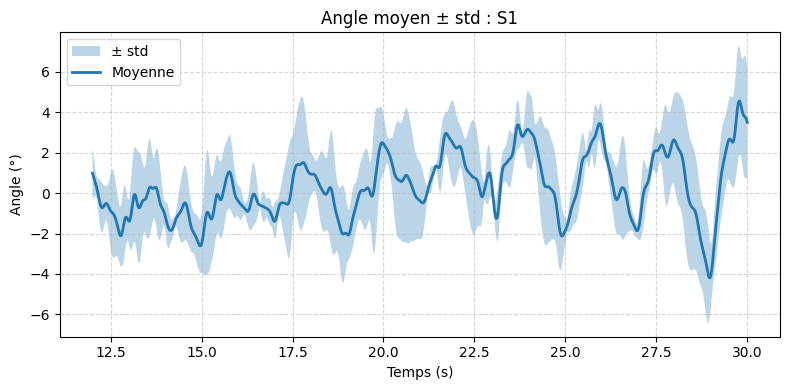

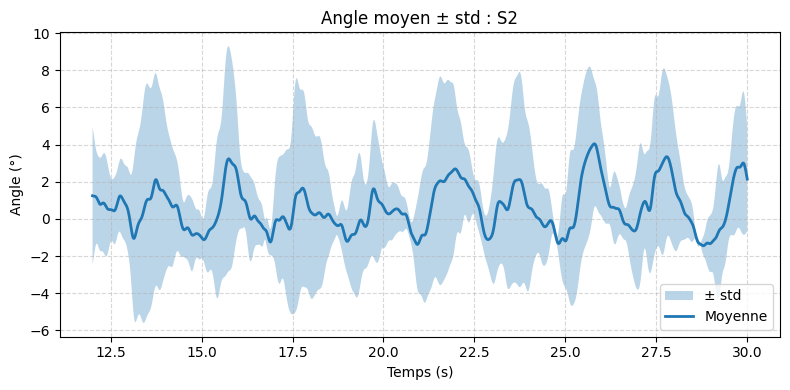

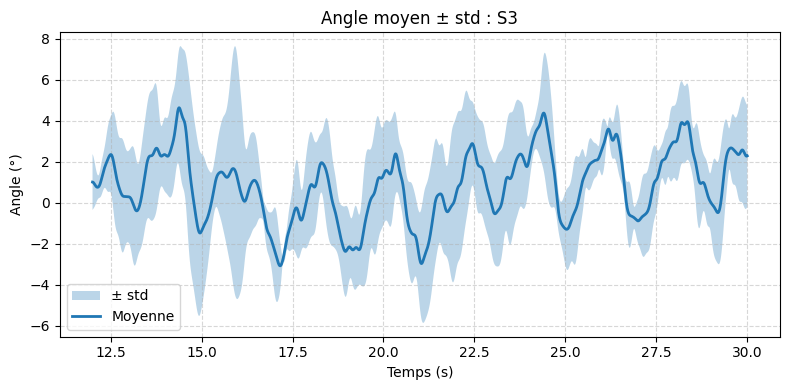

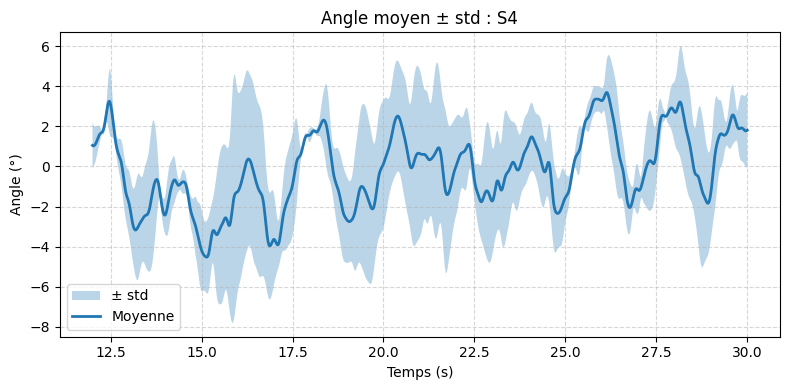

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# -----------------------
# Fenêtre de temps
# -----------------------
t_min_plot = 12
t_max_plot = 30
print(f"Fenêtre de temps pour le plot : {t_min_plot:.2f} → {t_max_plot:.2f} s")

# -----------------------
# Extraire les bases disponibles
# -----------------------
bases = sorted([
    c.split("_center")[0]
    for c in df_angle_base.columns
    if "_center_X" in c
])

# -----------------------
# Extraction STRICTE de S1 à S4 (ignore S01 etc.)
# -----------------------
def extract_S(base_name):
    m = re.search(r"(S[1-4])(?!\d)", base_name)
    return m.group(1) if m else None

# -----------------------
# Recalcul des angles (fenêtre de temps)
# -----------------------
angle_dict = {}

time_full = df_angle_base["Time"].values
time_mask = (time_full >= t_min_plot) & (time_full <= t_max_plot)
time_plot = time_full[time_mask]

for base in bases:
    cx = df_angle_base[f"{base}_center_X"].values[time_mask]
    cy = df_angle_base[f"{base}_center_Y"].values[time_mask]
    top_x = df_angle_base[f"{base}_top_X"].values[time_mask]
    top_y = df_angle_base[f"{base}_top_Z"].values[time_mask]  # FIX ICI
    
    vx = top_x - cx
    vy = top_y - cy
    angle = -np.degrees(np.arctan2(vx, vy))
    
    angle_dict[base] = angle

# -----------------------
# DataFrame long
# -----------------------
df_long = pd.DataFrame({
    "Time": np.tile(time_plot, len(bases)),
    "base": np.repeat(bases, len(time_plot)),
    "angle": np.concatenate([angle_dict[b] for b in bases])
})

# Ajouter S
df_long["S"] = df_long["base"].apply(extract_S)

# Garder uniquement S1 → S4
df_long = df_long[df_long["S"].notna()]

print(f"Nb de lignes après filtre S1–S4 : {len(df_long)}")

# -----------------------
# Moyenne et std par sujet
# -----------------------
df_mean_S = df_long.groupby(["Time", "S"]).agg(
    angle_mean=("angle", "mean"),
    angle_std=("angle", "std")
).reset_index()

# -----------------------
# Plot
# -----------------------
for S in sorted(df_mean_S["S"].unique(), key=lambda x: int(x[1:])):
    
    df_S = df_mean_S[df_mean_S["S"] == S]
    
    t = df_S["Time"].values
    y = df_S["angle_mean"].values
    y_std = df_S["angle_std"].values
    
    plt.figure(figsize=(8,4))
    
    plt.fill_between(
        t,
        y - y_std,
        y + y_std,
        alpha=0.3,
        label="± std"
    )
    
    plt.plot(t, y, linewidth=2, label="Moyenne")
    
    plt.title(f"Angle moyen ± std : {S}")
    plt.xlabel("Temps (s)")
    plt.ylabel("Angle (°)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [14]:
# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_save = os.path.join(dossier_root, "supera_manipu_S04")
os.makedirs(dossier_save, exist_ok=True)

time_col = "Time"
cmap = plt.cm.viridis

# ====== CONDITIONS DISPONIBLES ======
bases = sorted(set([c.split("_center")[0] for c in df_angle_base.columns if "_center_X" in c]))

# ====== BOUCLE SUR CHAQUE FICHIER ======
for base in bases:

    if base+"_X" not in minima_times_df.columns:
        continue

    center_x = df_angle_base[f"{base}_center_X"].values
    center_y = df_angle_base[f"{base}_center_Y"].values

    top_x = df_angle_base[f"{base}_top_X"].values
    top_z = df_angle_base[f"{base}_top_Z"].values

    # ===== vecteur centre → haut =====
    vx = top_x - center_x
    vy = top_z - center_y

    # ===== angle (positif vers gauche) =====
    angle = -np.degrees(np.arctan2(vx, vy))

    angle_df = pd.DataFrame({
        "Time": df_angle_base["Time"],
        "Angle": angle
    })

    minima_times = minima_times_df[base+"_X"].dropna().values

    if len(minima_times) < 2:
        continue

    # ===== FIGURE =====
    fig, ax = plt.subplots(figsize=(8,4))

    n_cycles = len(minima_times) - 1

    for i in range(n_cycles):

        t_start = minima_times[i]
        t_end = minima_times[i+1]

        mask = (angle_df["Time"] >= t_start) & (angle_df["Time"] <= t_end)

        t = angle_df["Time"][mask].values
        a = angle_df["Angle"][mask].values

        if len(t) == 0:
            continue

        t_norm = (t - t_start) / (t_end - t_start)

        color = cmap(i / max(1,n_cycles))

        ax.plot(t_norm, a, color=color)

    # ===== STYLE =====
    ax.set_xlabel("Progression du cycle")
    ax.set_ylabel("Angle du rectangle (°)")
    ax.set_title(f"Superposition cycles angle : {base}")
    ax.grid(True)

    # ===== COLORBAR =====
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=max(1,n_cycles)))
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Numéro cycle")

    fig.tight_layout()

    # ===== SAUVEGARDE =====
    save_path = os.path.join(dossier_save, f"angle_cycles_{base}.png")
    fig.savefig(save_path, dpi=150)

    plt.close(fig)

print(f"\n✅ Graphiques sauvegardés dans : {dossier_save}")


✅ Graphiques sauvegardés dans : Cinematique_S04_S\supera_manipu_S04


In [15]:
# ========================
# PARAMÈTRES
# ========================
npts_avg = 5

# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_angles = os.path.join(dossier_root, "angles_signes_s04")
os.makedirs(dossier_angles, exist_ok=True)

# ========================
# FONCTIONS
# ========================
def get_xz_bases(df):
    return sorted(
        {c[:-2] for c in df.columns if c.endswith("_X")}
        & {c[:-2] for c in df.columns if c.endswith("_Z")}
    )

def extract_cycles(mins, maxs):
    cycles = []
    for i in range(len(mins)-1):
        t_min1 = mins[i]
        t_min2 = mins[i+1]

        max_between = maxs[(maxs > t_min1) & (maxs < t_min2)]
        if len(max_between) == 0:
            continue

        t_max = max_between[0]
        cycles.append((t_min1, t_max, t_min2))
    return cycles

def angle_vs_vertical_signed(x0, y0, x1, y1):
    dx = -(x1 - x0)
    dy = abs(y1 - y0)
    return float(np.degrees(np.arctan2(dx, dy)))

def max_distance_to_line(x, y, x0, y0, x1, y1):
    vx, vy = x1 - x0, y1 - y0
    norm_v = np.hypot(vx, vy)
    if norm_v < 1e-12:
        return 0.0
    dist = np.abs((vy*(x - x0) - vx*(y - y0)) / norm_v)
    return float(np.max(dist))

# ========================
# DATAFRAME CENTRAL
# ========================
rows = []

xz_bases = get_xz_bases(df_final)

for base in xz_bases:

    colX = f"{base}_X"
    colZ = f"{base}_Z"

    if colZ not in minima_times_df.columns or colZ not in maxima_times_df.columns:
        continue

    mins = minima_times_df[colZ].dropna().values
    maxs = maxima_times_df[colZ].dropna().values

    cycles = extract_cycles(mins, maxs)

    for i, (t_min1, t_max, t_min2) in enumerate(cycles):

        # ========= ASC =========
        mask = (df_final["Time"] >= t_min1) & (df_final["Time"] <= t_max)
        x = df_final[colX][mask].values
        z = df_final[colZ][mask].values

        if len(x) >= 2*npts_avg+1:
            x0, z0 = np.mean(x[:npts_avg]), np.mean(z[:npts_avg])
            x1, z1 = np.mean(x[-npts_avg:]), np.mean(z[-npts_avg:])

            rows.append({
                "base": base,
                "cycle": i,
                "phase": "ASC",
                "t_start": t_min1,
                "t_end": t_max,
                "angle": angle_vs_vertical_signed(x0,z0,x1,z1),
                "dist": max_distance_to_line(x,z,x0,z0,x1,z1)
            })

        # ========= DESC =========
        mask = (df_final["Time"] >= t_max) & (df_final["Time"] <= t_min2)
        x = df_final[colX][mask].values
        z = df_final[colZ][mask].values

        if len(x) >= 2*npts_avg+1:
            x0, z0 = np.mean(x[:npts_avg]), np.mean(z[:npts_avg])
            x1, z1 = np.mean(x[-npts_avg:]), np.mean(z[-npts_avg:])

            rows.append({
                "base": base,
                "cycle": i,
                "phase": "DESC",
                "t_start": t_max,
                "t_end": t_min2,
                "angle": angle_vs_vertical_signed(x0,z0,x1,z1),
                "dist": max_distance_to_line(x,z,x0,z0,x1,z1)
            })

# Création DF
df_cycles = pd.DataFrame(rows)

print("✅ DataFrame central créé ")

print(f"✅ Paires XZ : {len(xz_bases)} trouvées.")

✅ DataFrame central créé 
✅ Paires XZ : 12 trouvées.


In [16]:
for base in df_cycles["base"].unique():

    df_b = df_cycles[df_cycles["base"] == base]

    for phase, color in [("ASC","blue"), ("DESC","orange")]:

        df_p = df_b[df_b["phase"] == phase]

        if len(df_p) == 0:
            continue

        # ANGLE
        plt.figure()
        plt.plot(df_p["cycle"], df_p["angle"], marker='o', color=color)
        plt.title(f"Angle {phase} – {base}")
        plt.grid()
        plt.savefig(os.path.join(dossier_angles, f"angle_{phase}_{base}.png"))
        plt.close()

        # DISTANCE
        plt.figure()
        plt.plot(df_p["cycle"], df_p["dist"], marker='o', color=color)
        plt.title(f"Dist {phase} – {base}")
        plt.grid()
        plt.savefig(os.path.join(dossier_angles, f"dist_{phase}_{base}.png"))
        plt.close()

    print(f"✅ Plots angles et dist enregistrés pour {base}")

✅ Plots angles et dist enregistrés pour S04_S1_13
✅ Plots angles et dist enregistrés pour S04_S1_14
✅ Plots angles et dist enregistrés pour S04_S1_15
✅ Plots angles et dist enregistrés pour S04_S2_16
✅ Plots angles et dist enregistrés pour S04_S2_17
✅ Plots angles et dist enregistrés pour S04_S2_18
✅ Plots angles et dist enregistrés pour S04_S3_19
✅ Plots angles et dist enregistrés pour S04_S3_20
✅ Plots angles et dist enregistrés pour S04_S3_21
✅ Plots angles et dist enregistrés pour S04_S4_22
✅ Plots angles et dist enregistrés pour S04_S4_23
✅ Plots angles et dist enregistrés pour S04_S4_24


In [17]:
import re

# ========================
# EXTRACTION PROPRE DE S (STRICT S1 à S4)
# ========================
def extract_S(base_name):
    m = re.search(r"(S[1-4])(?!\d)", base_name)
    return m.group(1) if m else None

df_cycles["S"] = df_cycles["base"].apply(extract_S)

# Garder uniquement S valides
df_cycles = df_cycles[df_cycles["S"].notna()]

# ========================
# 🔧 REINDEX DES CYCLES PAR FICHIER
# ========================

# Trier pour garantir l'ordre temporel
df_cycles = df_cycles.sort_values(["base", "t_start"])

# 1 cycle = ASC + DESC → donc 2 lignes
df_cycles["cycle_clean"] = df_cycles.groupby("base").cumcount() // 2 + 1

# ========================
# 🎯 DATAFRAME FINAL POUR STATS AVEC ÉCART-TYPE
# ========================

df_stats_S = df_cycles.groupby(["S", "cycle_clean", "phase"]).agg(
    angle_mean=("angle", "mean"),
    angle_std=("angle", "std"),
    dist_mean=("dist", "mean"),
    dist_std=("dist", "std")
).reset_index()

# ========================
# 🔍 TRI PROPRE DES S (S1 → S4)
# ========================
df_stats_S["S_num"] = df_stats_S["S"].str.extract(r"(\d+)").astype(int)

df_stats_S = df_stats_S.sort_values(
    ["S_num", "cycle_clean", "phase"]
).drop(columns="S_num")

# ========================
# 🔍 APERÇU PAR S
# ========================
print("\n🔍 Aperçu du début de chaque S :")

for S in sorted(df_stats_S["S"].unique(), key=lambda x: int(x[1:])):
    print(f"\n===== {S} =====")
    print(df_stats_S[df_stats_S["S"] == S].head())

# ========================
# 📊 AFFICHAGE COMPLET S1
# ========================
print("\n===== S1 COMPLET =====")

print(
    df_stats_S[df_stats_S["S"] == "S1"]
    .sort_values(["cycle_clean", "phase"])
    .to_string()
)


🔍 Aperçu du début de chaque S :

===== S1 =====
    S  cycle_clean phase  angle_mean  angle_std  dist_mean   dist_std
0  S1            1   ASC    4.388615   1.236700  17.665740   4.296955
1  S1            1  DESC   -5.328788   0.581990  10.928456  13.323948
2  S1            2   ASC    5.560956   0.567790  14.012265   8.682098
3  S1            2  DESC   -5.150319   0.859930   6.884739   0.888270
4  S1            3   ASC    2.365127   0.705143   8.168337   3.236477

===== S2 =====
     S  cycle_clean phase  angle_mean  angle_std  dist_mean  dist_std
26  S2            1   ASC    8.917388   3.529020   7.048112  1.798287
27  S2            1  DESC  -10.337826   2.691131   4.527975  0.663357
28  S2            2   ASC    7.617955   2.356944   5.958926  2.005577
29  S2            2  DESC   -9.174564   1.387101   9.769734  9.419160
30  S2            3   ASC    8.080824   4.210299  11.140097  6.910034

===== S3 =====
     S  cycle_clean phase  angle_mean  angle_std  dist_mean  dist_std
52  S3   

In [18]:
import statsmodels.formula.api as smf

# On peut créer un modèle pour un cycle et une phase
cycle = 1
phase = "ASC"

# Sous-df (stats)
df_sub = df_stats_S[
    (df_stats_S["phase"] == phase) &
    (df_stats_S["cycle_clean"] == cycle)
]

# Vérifier qu'on a assez de sujets
if df_sub["S"].nunique() >= 2:
    
    # Utiliser les données brutes
    df_sub_original = df_cycles[
        (df_cycles["phase"] == phase) &
        (df_cycles["cycle_clean"] == cycle)
    ]
    
    # IMPORTANT : garder uniquement S valides
    df_sub_original = df_sub_original[df_sub_original["S"].notna()]
    
    # ========================
    # Modèle mixte : angle ~ S + (1 | base)
    # ========================
    md = smf.mixedlm(
        "angle ~ C(S)",
        df_sub_original,
        groups=df_sub_original["base"]
    )
    
    mdf = md.fit(reml=True)
    
    print(mdf.summary())

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: angle   
No. Observations: 12      Method:             REML    
No. Groups:       12      Scale:              4.6691  
Min. group size:  1       Log-Likelihood:     -22.4852
Max. group size:  1       Converged:          Yes     
Mean group size:  1.0                                 
------------------------------------------------------
              Coef. Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------
Intercept     4.389    1.730 2.537 0.011  0.998  7.779
C(S)[T.S2]    4.529    2.339 1.936 0.053 -0.055  9.113
C(S)[T.S3]    2.029    2.489 0.815 0.415 -2.849  6.907
C(S)[T.S4]    2.350    2.339 1.005 0.315 -2.234  6.934
Group Var     4.669                                   



C:\Users\nicom\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


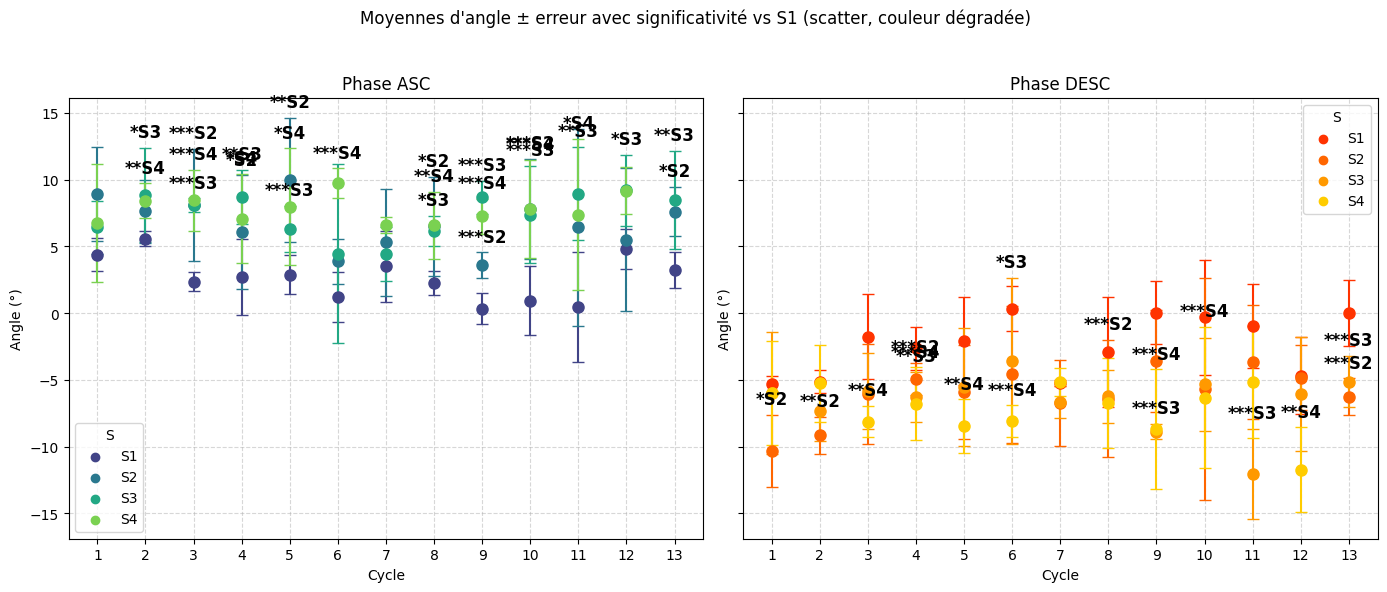

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import warnings
import matplotlib.cm as cm
import statsmodels.formula.api as smf

# -----------------------
# Ignorer warnings inutiles
# -----------------------
warnings.filterwarnings("ignore")

# -----------------------
# Paramètres du plot
# -----------------------
S_order = ["S1","S2","S3","S4"]

phase_colors = {
    "ASC": cm.viridis(np.linspace(0.2,0.8,len(S_order))),   # vert → violet
    "DESC": cm.autumn(np.linspace(0.2,0.8,len(S_order)))     # jaune → rouge
}

# -----------------------
# Préparer figure
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
phases = df_stats_S["phase"].unique()

for ax, phase in zip(axes, phases):
    
    cycles_phase = sorted(
        df_stats_S[df_stats_S["phase"]==phase]["cycle_clean"].unique()
    )
    
    for i, S in enumerate(S_order):
        
        df_S = df_stats_S[
            (df_stats_S["phase"]==phase) &
            (df_stats_S["S"]==S)
        ]
        
        if df_S.empty:
            continue
        
        color = phase_colors[phase][i]
        
        # tracer point par cycle
        for cycle in cycles_phase:
            
            df_cycle = df_S[df_S["cycle_clean"]==cycle]
            if df_cycle.empty:
                continue
            
            mean_val = df_cycle["angle_mean"].values[0]
            err_val = df_cycle["angle_std"].values[0]
            
            # scatter + barre d'erreur
            ax.errorbar(
                cycle, mean_val, yerr=err_val,
                fmt='o', color=color,
                capsize=4, markersize=8
            )
            
            # -----------------------
            # ⭐ Significativité vs S1
            # -----------------------
            if S != "S1":
                
                df_mixed = df_cycles[
                    (df_cycles["phase"]==phase) &
                    (df_cycles["cycle_clean"]==cycle)
                ]
                
                # garder seulement S valides
                df_mixed = df_mixed[df_mixed["S"].notna()]
                
                try:
                    md = smf.mixedlm(
                        "angle ~ C(S)",
                        df_mixed,
                        groups=df_mixed["base"]
                    )
                    
                    mdf = md.fit(reml=True)
                    p_val = mdf.pvalues.get(f"C(S)[T.{S}]", 1.0)
                    
                    if p_val < 0.05:
                        star = "***"+S if p_val<0.001 else "**"+S if p_val<0.01 else "*"+S
                        
                        ax.text(
                            cycle,
                            mean_val + err_val + 0.5,
                            star,
                            ha="center",
                            va="bottom",
                            fontsize=12,
                            fontweight="bold"
                        )
                except:
                    pass
    
    # -----------------------
    # Style axes
    # -----------------------
    ax.set_title(f"Phase {phase}")
    ax.set_xlabel("Cycle")
    ax.set_xticks(cycles_phase)
    ax.set_xticklabels([str(c) for c in cycles_phase])
    ax.set_ylabel("Angle (°)")
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Légende
    for i, S in enumerate(S_order):
        ax.scatter([], [], color=phase_colors[phase][i], label=S)
    
    ax.legend(title="S")

# -----------------------
# Titre global
# -----------------------
plt.suptitle(
    "Moyennes d'angle ± erreur avec significativité vs S1 (scatter, couleur dégradée)"
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [20]:
import statsmodels.formula.api as smf

# Exemple pour un cycle et une phase
cycle = 1
phase = "ASC"

# Sous-df
df_sub = df_stats_S[(df_stats_S["phase"] == phase) & (df_stats_S["cycle_clean"] == cycle)]

# Assurer qu'on a assez de niveaux S
if df_sub["S"].nunique() >= 2:
    
    # Utiliser df_cycles original pour les observations brutes (pas les moyennes)
    df_sub_original = df_cycles[
        (df_cycles["phase"] == phase) & (df_cycles["cycle_clean"] == cycle)
    ]
    
    # Modèle mixte : dist ~ S + (1 | base)
    md = smf.mixedlm("dist ~ C(S)", df_sub_original, groups=df_sub_original["base"])
    mdf = md.fit(reml=True)
    
    print(mdf.summary())

         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: dist    
No. Observations:  12      Method:             REML    
No. Groups:        12      Scale:              13.5530 
Min. group size:   1       Log-Likelihood:     -26.7477
Max. group size:   1       Converged:          Yes     
Mean group size:   1.0                                 
-------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------
Intercept   17.666    2.033  8.688 0.000  13.680 21.651
C(S)[T.S2] -10.618    4.169 -2.547 0.011 -18.789 -2.446
C(S)[T.S3] -12.632    3.913 -3.228 0.001 -20.302 -4.962
C(S)[T.S4]  -8.956    4.169 -2.148 0.032 -17.127 -0.784
Group Var   13.553                                     



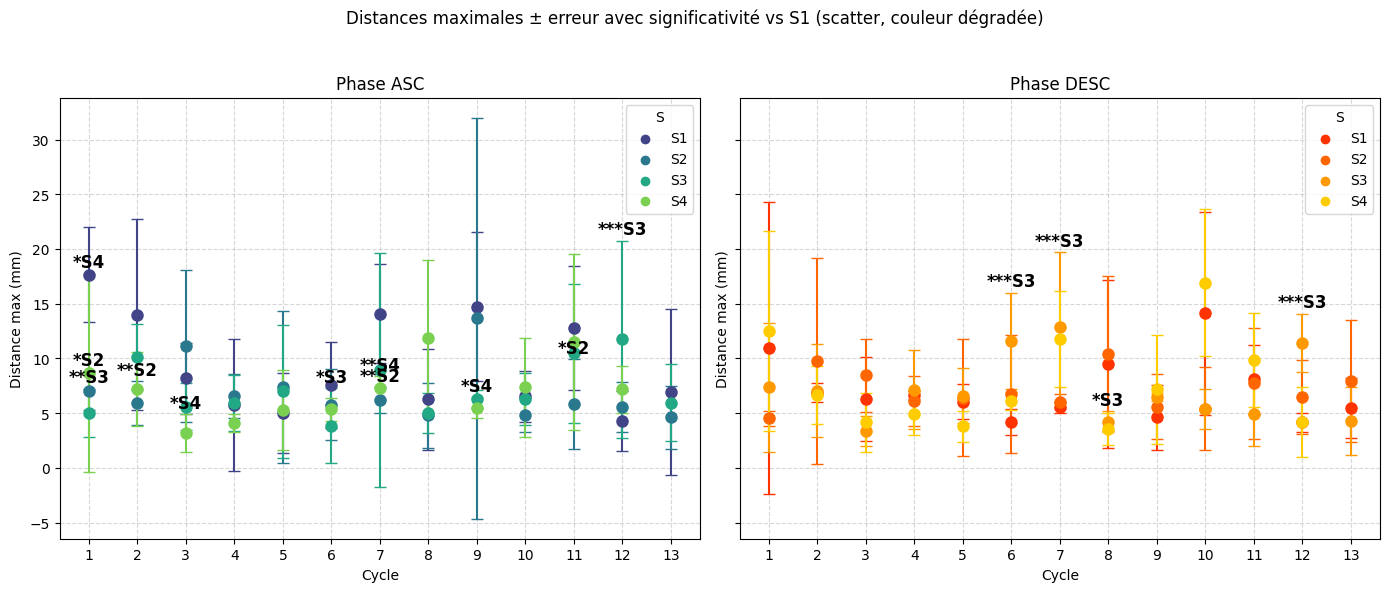

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import warnings
import matplotlib.cm as cm
import statsmodels.formula.api as smf

# -----------------------
# Ignorer warnings inutiles
# -----------------------
warnings.filterwarnings("ignore")

# -----------------------
# Paramètres du plot
# -----------------------
S_order = ["S1","S2","S3","S4"]
phase_colors = {
    "ASC": cm.viridis(np.linspace(0.2,0.8,len(S_order))),   # vert → violet
    "DESC": cm.autumn(np.linspace(0.2,0.8,len(S_order)))     # jaune → rouge
}
error_type = "std"  # std ou sem

# -----------------------
# Préparer figure
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
phases = df_stats_S["phase"].unique()

for ax, phase in zip(axes, phases):
    cycles_phase = sorted(df_stats_S[df_stats_S["phase"]==phase]["cycle_clean"].unique())
    
    for i, S in enumerate(S_order):
        df_S = df_stats_S[(df_stats_S["phase"]==phase) & (df_stats_S["S"]==S)]
        if df_S.empty:
            continue
        
        color = phase_colors[phase][i]
        
        # tracer point par cycle
        for cycle in cycles_phase:
            df_cycle = df_S[df_S["cycle_clean"]==cycle]
            if df_cycle.empty:
                continue
            
            mean_val = df_cycle["dist_mean"].values[0]
            err_val = df_cycle["dist_std"].values[0]
            
            # scatter + barre d'erreur
            ax.errorbar(cycle, mean_val, yerr=err_val, fmt='o',
                        color=color, capsize=4, markersize=8)
            
            # -----------------------
            # Ajouter étoiles significatives vs S1
            # -----------------------
            if S != "S1":
                df_mixed = df_cycles[(df_cycles["phase"]==phase) & (df_cycles["cycle_clean"]==cycle)]
                try:
                    md = smf.mixedlm("dist ~ C(S)", df_mixed, groups=df_mixed["base"])
                    mdf = md.fit(reml=True)
                    pvals = mdf.pvalues
                    p_val = pvals.get(f"C(S)[T.{S}]", 1.0)
                    if p_val < 0.05:
                        star = "***"+S if p_val<0.001 else "**"+S if p_val<0.01 else "*"+S
                        ax.text(cycle, mean_val + err_val + 0.2, star,
                                ha="center", va="bottom", fontsize=12, fontweight="bold")
                except:
                    pass
    
    # Style axes
    ax.set_title(f"Phase {phase}")
    ax.set_xlabel("Cycle")
    ax.set_xticks(cycles_phase)
    ax.set_xticklabels([str(c) for c in cycles_phase])
    ax.set_ylabel("Distance max (mm)")
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Légende
    for i, S in enumerate(S_order):
        ax.scatter([], [], color=phase_colors[phase][i], label=S)
    ax.legend(title="S")

plt.suptitle("Distances maximales ± erreur avec significativité vs S1 (scatter, couleur dégradée)")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [22]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
import warnings

warnings.filterwarnings("ignore")

# ========================
# Fonction sinus et R²
# ========================
def sin_model(t, A, w, phi):
    return A * np.sin(w*t + phi)

def residual_vs_sinusoidal(signal):
    """Retourne 1-R² du signal ajusté à un sinus (0 = parfait sinus)"""
    if len(signal) < 5:  # trop court pour ajuster
        return np.nan
    t = np.arange(len(signal))
    mean_val = np.mean(signal)
    try:
        params, _ = curve_fit(
            sin_model, t, signal - mean_val,
            p0=[np.ptp(signal)/2, 2*np.pi/len(signal), 0]
        )
        fitted = sin_model(t, *params) + mean_val
        residual = signal - fitted
        r_squared = 1 - np.var(residual)/np.var(signal)
        return 1 - r_squared  # distance au sinus
    except:
        return np.nan

# ========================
# Calcul distance au sinus pour tous cycles et fichiers (angles)
# ========================
records = []
for phase in df_cycles["phase"].unique():
    for cycle in df_cycles["cycle_clean"].unique():
        df_cycle = df_cycles[(df_cycles["phase"]==phase) & (df_cycles["cycle_clean"]==cycle)]
        if df_cycle.empty or df_cycle["S"].nunique() < 2:
            continue
        for S in df_cycle["S"].unique():
            df_S = df_cycle[df_cycle["S"]==S]
            for base in df_S["base"].unique():
                sig = df_S[df_S["base"]==base]["angle"].values
                dist_sin = residual_vs_sinusoidal(sig)
                records.append({
                    "phase": phase,
                    "cycle": cycle,
                    "S": S,
                    "base": base,
                    "dist_sinus": dist_sin
                })

df_sinus_angles = pd.DataFrame(records)
print("✅ DataFrame distances au sinus (angles) créé")
print(df_sinus_angles.head())

# ========================
# Modèles mixtes : dist_sinus ~ S + (1|base)
# ========================
results = []
for phase in df_sinus_angles["phase"].unique():
    for cycle in df_sinus_angles["cycle"].unique():
        df_sub = df_sinus_angles[
            (df_sinus_angles["phase"]==phase) &
            (df_sinus_angles["cycle"]==cycle)
        ].dropna(subset=["dist_sinus"])
        if df_sub["S"].nunique() < 2:
            continue
        try:
            md = smf.mixedlm("dist_sinus ~ C(S)", df_sub, groups=df_sub["base"])
            mdf = md.fit(reml=True)
            for S in df_sub["S"].unique():
                if S == "S1":
                    continue
                coef = mdf.params.get(f"C(S)[T.{S}]", np.nan)
                p_val = mdf.pvalues.get(f"C(S)[T.{S}]", np.nan)
                results.append({
                    "phase": phase,
                    "cycle": cycle,
                    "S": S,
                    "coef_vs_S1": coef,
                    "p_value_vs_S1": p_val
                })
        except:
            print(f"⚠️ Modèle mixte n’a pas convergé : phase={phase}, cycle={cycle}")
            continue

df_mixed_sinus_angles = pd.DataFrame(results)
print("✅ Modèles mixtes distances au sinus (angles) créés")
print(df_mixed_sinus_angles.head(20))

✅ DataFrame distances au sinus (angles) créé
  phase  cycle   S       base  dist_sinus
0   ASC      1  S1  S04_S1_13         NaN
1   ASC      1  S1  S04_S1_14         NaN
2   ASC      1  S1  S04_S1_15         NaN
3   ASC      1  S2  S04_S2_16         NaN
4   ASC      1  S2  S04_S2_17         NaN
✅ Modèles mixtes distances au sinus (angles) créés
Empty DataFrame
Columns: []
Index: []


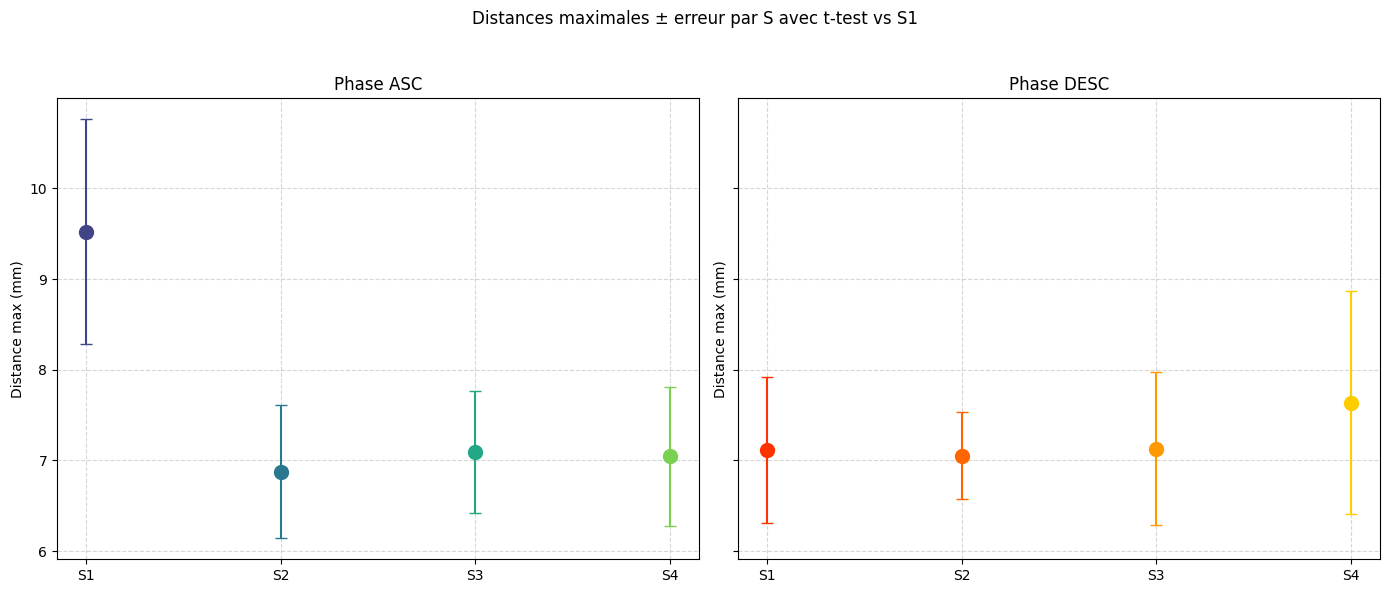

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import ttest_ind
import warnings

warnings.filterwarnings("ignore")

# -----------------------
# Paramètres
# -----------------------
S_order = ["S1","S2","S3","S4"]
phase_colors = {
    "ASC": cm.viridis(np.linspace(0.2,0.8,len(S_order))),
    "DESC": cm.autumn(np.linspace(0.2,0.8,len(S_order)))
}
error_type = "std"  # std ou sem

# -----------------------
# Préparer figure
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
phases = df_stats_S["phase"].unique()

for ax, phase in zip(axes, phases):
    df_phase = df_stats_S[df_stats_S["phase"]==phase]

    # Moyenne et écart type par S (propagation std)
    df_S_stats = df_phase.groupby("S").agg(
        mean_val=("dist_mean","mean"),
        std_val=("dist_mean","std"),
        n=("dist_mean","count")
    ).reset_index()
    df_S_stats["std_err"] = df_S_stats["std_val"]/np.sqrt(df_S_stats["n"])
    
    for i, S in enumerate(S_order):
        row = df_S_stats[df_S_stats["S"]==S]
        if row.empty:
            continue
        mean_val = row["mean_val"].values[0]
        std_err = row["std_err"].values[0]
        color = phase_colors[phase][i]

        ax.errorbar(i, mean_val, yerr=std_err, fmt='o', color=color,
                    capsize=4, markersize=10)

        # Test t-test vs S1
        if S != "S1":
            data_S = df_phase[df_phase["S"]==S]["dist_mean"].values
            data_S1 = df_phase[df_phase["S"]=="S1"]["dist_mean"].values
            try:
                t_stat, p_val = ttest_ind(data_S, data_S1, equal_var=False)
                if p_val < 0.05:
                    star = "***" if p_val<0.001 else "**" if p_val<0.01 else "*"
                    ax.text(i, mean_val + std_err + 0.2, star,
                            ha="center", va="bottom", fontsize=14, fontweight="bold")
            except:
                pass

    ax.set_title(f"Phase {phase}")
    ax.set_xticks(range(len(S_order)))
    ax.set_xticklabels(S_order)
    ax.set_ylabel("Distance max (mm)")
    ax.grid(True, linestyle="--", alpha=0.5)
    
plt.suptitle("Distances maximales ± erreur par S avec t-test vs S1")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

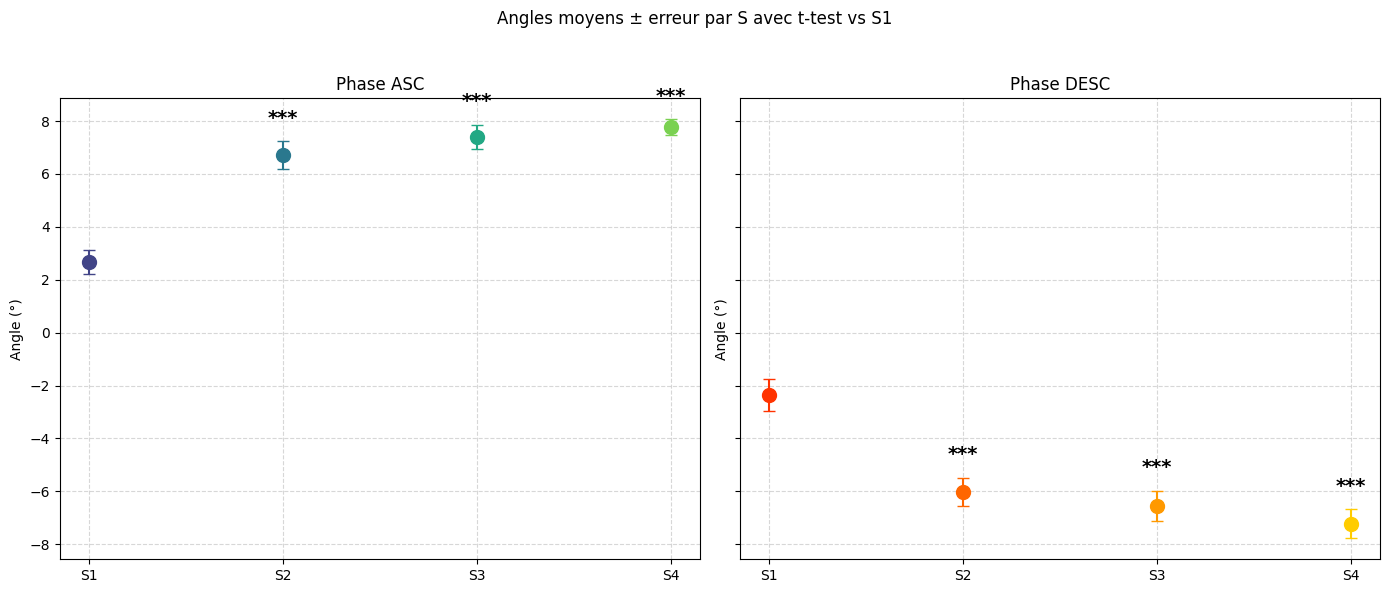

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import ttest_ind
import warnings

warnings.filterwarnings("ignore")

# -----------------------
# Paramètres
# -----------------------
S_order = ["S1","S2","S3","S4"]
phase_colors = {
    "ASC": cm.viridis(np.linspace(0.2,0.8,len(S_order))),
    "DESC": cm.autumn(np.linspace(0.2,0.8,len(S_order)))
}
error_type = "std"  # std ou sem

# -----------------------
# Préparer figure
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
phases = df_stats_S["phase"].unique()

for ax, phase in zip(axes, phases):
    df_phase = df_stats_S[df_stats_S["phase"]==phase]

    # Moyenne et écart type par S (propagation std)
    df_S_stats = df_phase.groupby("S").agg(
        mean_val=("angle_mean","mean"),
        std_val=("angle_mean","std"),
        n=("angle_mean","count")
    ).reset_index()
    df_S_stats["std_err"] = df_S_stats["std_val"]/np.sqrt(df_S_stats["n"])
    
    for i, S in enumerate(S_order):
        row = df_S_stats[df_S_stats["S"]==S]
        if row.empty:
            continue
        mean_val = row["mean_val"].values[0]
        std_err = row["std_err"].values[0]
        color = phase_colors[phase][i]

        ax.errorbar(i, mean_val, yerr=std_err, fmt='o', color=color,
                    capsize=4, markersize=10)

        # Test t-test vs S1
        if S != "S1":
            data_S = df_phase[df_phase["S"]==S]["angle_mean"].values
            data_S1 = df_phase[df_phase["S"]=="S1"]["angle_mean"].values
            try:
                t_stat, p_val = ttest_ind(data_S, data_S1, equal_var=False)
                if p_val < 0.05:
                    star = "***" if p_val<0.001 else "**" if p_val<0.01 else "*"
                    ax.text(i, mean_val + std_err + 0.5, star,
                            ha="center", va="bottom", fontsize=14, fontweight="bold")
            except:
                pass

    ax.set_title(f"Phase {phase}")
    ax.set_xticks(range(len(S_order)))
    ax.set_xticklabels(S_order)
    ax.set_ylabel("Angle (°)")
    ax.grid(True, linestyle="--", alpha=0.5)
    
plt.suptitle("Angles moyens ± erreur par S avec t-test vs S1")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [25]:
# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_phase = os.path.join(dossier_root, "diagramme_phase_s04")
os.makedirs(dossier_phase, exist_ok=True)

for base in df_cycles["base"].unique():

    colX = f"{base}_X"
    colZ = f"{base}_Y"

    df_b = df_cycles[df_cycles["base"] == base]

    X_full, Y_full = [], []

    for _, row in df_b.iterrows():
        mask = (df_final["Time"] >= row["t_start"]) & (df_final["Time"] <= row["t_end"])
        X_full.extend(df_final[colX][mask].values)
        Y_full.extend(df_final[colZ][mask].values)

    plt.figure(figsize=(6,6))
    plt.plot(X_full, Y_full)
    plt.axis('equal')
    plt.grid()
    plt.title(f"Phase globale – {base}")
    plt.savefig(os.path.join(dossier_phase, f"{base}.png"))
    plt.close()
    
    print(f"✅ Diagrammes de phase complet enregistrés pour {base}")

✅ Diagrammes de phase complet enregistrés pour S04_S1_13
✅ Diagrammes de phase complet enregistrés pour S04_S1_14
✅ Diagrammes de phase complet enregistrés pour S04_S1_15
✅ Diagrammes de phase complet enregistrés pour S04_S2_16
✅ Diagrammes de phase complet enregistrés pour S04_S2_17
✅ Diagrammes de phase complet enregistrés pour S04_S2_18
✅ Diagrammes de phase complet enregistrés pour S04_S3_19
✅ Diagrammes de phase complet enregistrés pour S04_S3_20
✅ Diagrammes de phase complet enregistrés pour S04_S3_21
✅ Diagrammes de phase complet enregistrés pour S04_S4_22
✅ Diagrammes de phase complet enregistrés pour S04_S4_23
✅ Diagrammes de phase complet enregistrés pour S04_S4_24


In [26]:
# ====== DOSSIER DES PLOTS ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

dossier_phase_sep = os.path.join(dossier_root, "diagramme_phase_sep_s04")
os.makedirs(dossier_phase_sep, exist_ok=True)

for base in df_cycles["base"].unique():

    colX = f"{base}_X"
    colZ = f"{base}_Z"

    df_b = df_cycles[df_cycles["base"] == base]

    for phase, color in [("ASC","green"), ("DESC","red")]:

        df_p = df_b[df_b["phase"] == phase]

        X, Z = [], []

        for _, row in df_p.iterrows():
            mask = (df_final["Time"] >= row["t_start"]) & (df_final["Time"] <= row["t_end"])
            X.extend(df_final[colX][mask].values)
            Z.extend(df_final[colZ][mask].values)

        if len(X) == 0:
            continue

        plt.figure(figsize=(6,6))
        plt.plot(X, Z, color=color)
        plt.axis('equal')
        plt.grid()
        plt.title(f"{phase} – {base}")
        plt.savefig(os.path.join(dossier_phase_sep, f"{phase}_{base}.png"))
        plt.close()

    print(f"✅ Diagrammes ASC et DESC pour {base}")

✅ Diagrammes ASC et DESC pour S04_S1_13
✅ Diagrammes ASC et DESC pour S04_S1_14
✅ Diagrammes ASC et DESC pour S04_S1_15
✅ Diagrammes ASC et DESC pour S04_S2_16
✅ Diagrammes ASC et DESC pour S04_S2_17
✅ Diagrammes ASC et DESC pour S04_S2_18
✅ Diagrammes ASC et DESC pour S04_S3_19
✅ Diagrammes ASC et DESC pour S04_S3_20
✅ Diagrammes ASC et DESC pour S04_S3_21
✅ Diagrammes ASC et DESC pour S04_S4_22
✅ Diagrammes ASC et DESC pour S04_S4_23
✅ Diagrammes ASC et DESC pour S04_S4_24


In [27]:
# ====== DOSSIER RACINE ======
dossier_root = "Cinematique_S04_S"
os.makedirs(dossier_root, exist_ok=True)

# ====== DOSSIER DES PLOTS SHIFT + MOYENNE ======
dossier_phase_shift = os.path.join(dossier_root, "diagramme_phase_shift_s04")
os.makedirs(dossier_phase_shift, exist_ok=True)

# ====== LISTE DES BASES XY ======
xy_bases = sorted(
    {c[:-2] for c in df_final.columns if c.endswith("_X")}
    & {c[:-2] for c in df_final.columns if c.endswith("_Z")}
)
print(f"✅ Paires XY détectées : {len(xy_bases)}")

# ====== BOUCLE SUR LES BASES ======
for base in xy_bases:

    colX = f"{base}_X"
    colZ = f"{base}_Z"

    if colZ not in minima_times_df.columns or colZ not in maxima_times_df.columns:
        print(f"⚠️ Pas d’extréma pour {base}, skip.")
        continue

    mins = minima_times_df[colZ].dropna().values
    maxs = maxima_times_df[colZ].dropna().values

    # ====== LISTES DE STOCKAGE DES CYCLES ======
    X_ASC_cycles = []
    Z_ASC_cycles = []
    X_DESC_cycles = []
    Z_DESC_cycles = []

    # ====== EXTRACTION DES CYCLES ======
    for i in range(len(mins)-1):

        t_min1 = mins[i]
        t_min2 = mins[i+1]

        max_between = maxs[(maxs > t_min1) & (maxs < t_min2)]
        if len(max_between) == 0:
            continue

        t_max = max_between[0]

        # --- Phase ASC ---
        mask_asc = (df_final["Time"] >= t_min1) & (df_final["Time"] <= t_max)
        Xa = df_final[colX][mask_asc].values
        Za = df_final[colZ][mask_asc].values

        # Shift min à 0
        Xa_shift = Xa - Xa[0]
        Za_shift = Za - Za[0]

        X_ASC_cycles.append(Xa_shift)
        Z_ASC_cycles.append(Za_shift)

        # --- Phase DESC ---
        mask_desc = (df_final["Time"] >= t_max) & (df_final["Time"] <= t_min2)
        Xd = df_final[colX][mask_desc].values
        Zd = df_final[colZ][mask_desc].values

        Xd_shift = Xd - Xd[0]
        Zd_shift = Zd - Zd[0]

        X_DESC_cycles.append(Xd_shift)
        Z_DESC_cycles.append(Zd_shift)

    # ====== FONCTION POUR MOYENNE INTERPOLÉE ======
    def compute_mean_curve(list_X, list_Y, N=200):
        if len(list_X) == 0:
            return None, None
        t_common = np.linspace(0, 1, N)
        X_interp = []
        Y_interp = []
        for Xc, Yc in zip(list_X, list_Y):
            t_orig = np.linspace(0, 1, len(Xc))
            X_interp.append(np.interp(t_common, t_orig, Xc))
            Y_interp.append(np.interp(t_common, t_orig, Yc))
        X_mean = np.mean(np.array(X_interp), axis=0)
        Y_mean = np.mean(np.array(Y_interp), axis=0)
        return X_mean, Y_mean

    X_ASC_mean, Z_ASC_mean = compute_mean_curve(X_ASC_cycles, Z_ASC_cycles)
    X_DESC_mean, Z_DESC_mean = compute_mean_curve(X_DESC_cycles, Z_DESC_cycles)

    # ====== PLOT PHASE ASC ======
    if len(X_ASC_cycles) > 0:
        plt.figure(figsize=(6,6))
        # Cycles transparents
        for Xc, Zc in zip(X_ASC_cycles, Z_ASC_cycles):
            plt.plot(Xc, Zc, color='green', alpha=0.25)
        # Moyenne
        if X_ASC_mean is not None:
            plt.plot(X_ASC_mean, Z_ASC_mean, color='black', linewidth=2)
        plt.xlabel("X shifté")
        plt.ylabel("Z shifté (min=0)")
        plt.title(f"Phase ASC – Moyenne + cycles – {base}")
        plt.grid(True)
        plt.axis("equal")
        plt.tight_layout()
        plt.savefig(os.path.join(dossier_phase_shift, f"phase_ASC_shift_{base}.png"), dpi=150)
        plt.close()

    # ====== PLOT PHASE DESC ======
    if len(X_DESC_cycles) > 0:
        plt.figure(figsize=(6,6))
        for Xc, Zc in zip(X_DESC_cycles, Z_DESC_cycles):
            plt.plot(Xc, Zc, color='red', alpha=0.25)
        if X_DESC_mean is not None:
            plt.plot(X_DESC_mean, Z_DESC_mean, color='black', linewidth=2)
        plt.xlabel("X shifté")
        plt.ylabel("Z shifté (max=0)")
        plt.title(f"Phase DESC – Moyenne + cycles – {base}")
        plt.grid(True)
        plt.axis("equal")
        plt.tight_layout()
        plt.savefig(os.path.join(dossier_phase_shift, f"phase_DESC_shift_{base}.png"), dpi=150)
        plt.close()

    print(f"✅ Diagrammes SHIFT + MOYENNE enregistrés pour {base}")

✅ Paires XY détectées : 12
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S1_13
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S1_14
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S1_15
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S2_16
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S2_17
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S2_18
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S3_19
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S3_20
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S3_21
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S4_22
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S4_23
✅ Diagrammes SHIFT + MOYENNE enregistrés pour S04_S4_24


✅ Bases détectées : ['S04_S1_13', 'S04_S1_14', 'S04_S1_15', 'S04_S2_16', 'S04_S2_17', 'S04_S2_18', 'S04_S3_19', 'S04_S3_20', 'S04_S3_21', 'S04_S4_22', 'S04_S4_23', 'S04_S4_24']


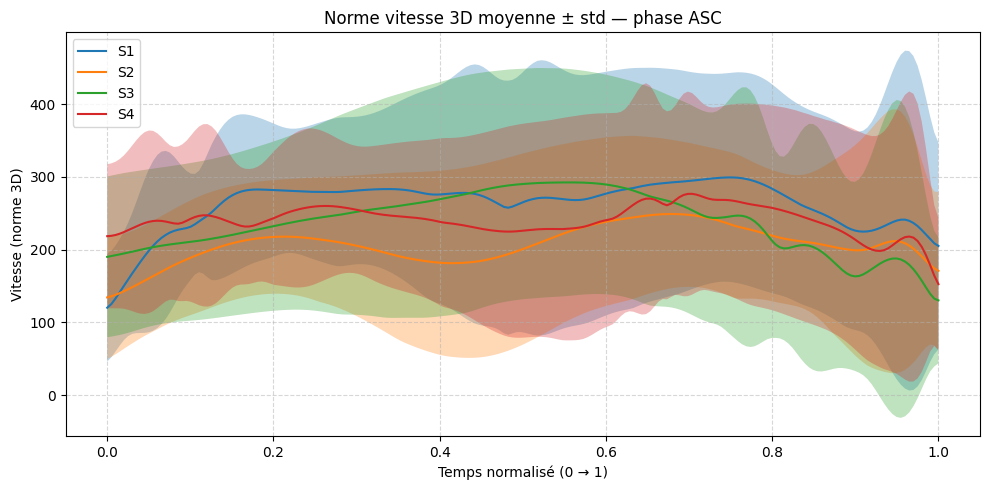

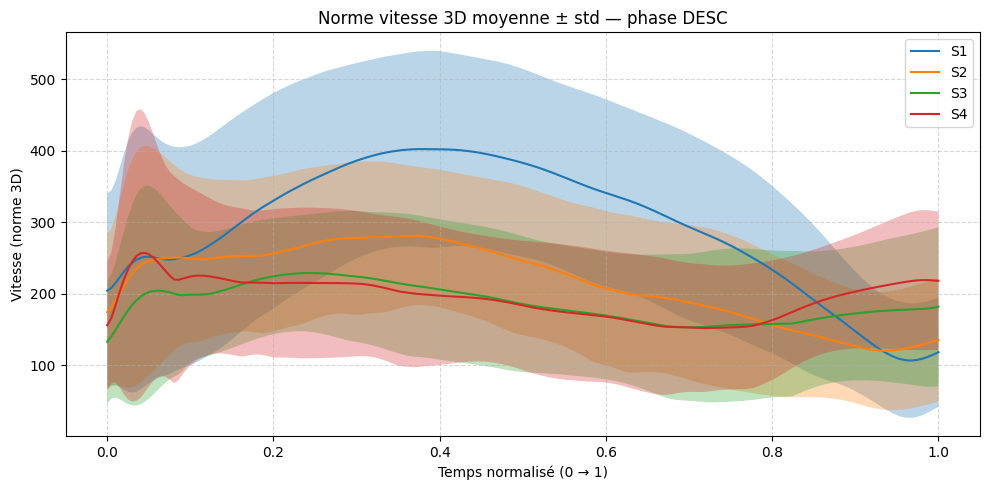

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy import stats

# ========================
# PARAMETRES
# ========================
time_col = "Time"
n_points = 200
t_norm = np.linspace(0, 1, n_points)
time_vals = velocities[time_col].values

# récupérer les bases uniques (sans _X _Y _Z)
bases = sorted(set([c.rsplit("_",1)[0] for c in velocities.columns if c != time_col]))
print("✅ Bases détectées :", bases)

# ========================
# FONCTION EXTRACTION S CORRIGEE
# ========================
def extract_S_corrected(name):
    """
    Extrait S1, S2, S3 ou S4 du nom de base en ignorant les préfixes.
    Exemple : 'S01_S3_25' → 'S3'
    """
    m = re.search(r"_?(S[1-4])_", name)
    return m.group(1) if m else "UNKNOWN"

# ========================
# STOCKAGE PAR S
# ========================
data_up = {S: [] for S in ["S1","S2","S3","S4"]}
data_down = {S: [] for S in ["S1","S2","S3","S4"]}

# ========================
# LOOP SUR CHAQUE BASE (X,Y,Z → norme)
# ========================
for base in bases:

    col_x = f"{base}_X"
    col_y = f"{base}_Y"
    col_z = f"{base}_Z"

    # Vérifier l'existence des colonnes
    if not all(c in velocities.columns for c in [col_x, col_y, col_z]):
        print(f"⚠️ Colonnes manquantes pour {base} : {[c for c in [col_x,col_y,col_z] if c not in velocities.columns]}")
        continue

    col_ref = col_y
    if col_ref not in minima_times_df.columns or col_ref not in maxima_times_df.columns:
        print(f"⚠️ Colonnes minima/maxima manquantes pour {col_ref}")
        continue

    S = extract_S_corrected(base)
    if S not in data_up:
        print(f"⚠️ Base {S} ignorée (clé non prévue)")
        continue

    minima_times = minima_times_df[col_ref].dropna().values
    maxima_times = maxima_times_df[col_ref].dropna().values

    vx = velocities[col_x].values
    vy = velocities[col_y].values
    vz = velocities[col_z].values

    speed = np.sqrt(vx**2 + vy**2 + vz**2)

    # ===== ASC (min → max) =====
    asc_count = 0
    for t_min in minima_times:
        max_after = maxima_times[maxima_times > t_min]
        if len(max_after) == 0:
            continue
        t_max = max_after[0]
        mask = (time_vals >= t_min) & (time_vals <= t_max)
        seg_v = speed[mask]
        if len(seg_v) < 10:
            continue
        t_scaled = (time_vals[mask] - time_vals[mask][0]) / (time_vals[mask][-1] - time_vals[mask][0])
        v_interp = np.interp(t_norm, t_scaled, seg_v)
        data_up[S].append(v_interp)
        asc_count += 1


    # ===== DESC (max → min) =====
    desc_count = 0
    for t_max in maxima_times:
        min_after = minima_times[minima_times > t_max]
        if len(min_after) == 0:
            continue
        t_min = min_after[0]
        mask = (time_vals >= t_max) & (time_vals <= t_min)
        seg_v = speed[mask]
        if len(seg_v) < 10:
            continue
        t_scaled = (time_vals[mask] - time_vals[mask][0]) / (time_vals[mask][-1] - time_vals[mask][0])
        v_interp = np.interp(t_norm, t_scaled, seg_v)
        data_down[S].append(v_interp)
        desc_count += 1
  

# ========================
# CALCUL RTPV + TIMING %
# ========================
records = []

def compute_rtpv(curve):
    """Retourne l'indice du pic normalisé en % du mouvement"""
    peak_idx = np.argmax(curve)
    return peak_idx / len(curve) * 100

for phase_name, dataset in zip(["ASC","DESC"], [data_up, data_down]):
    for S, curves in dataset.items():
        for curve in curves:
            rtpv_percent = compute_rtpv(curve)
            records.append({
                "S": S,
                "phase": phase_name,
                "rtpv_percent": rtpv_percent
            })

df_peak = pd.DataFrame(records)

# ========================
# PLOT MOYENNE ± STD
# ========================
for phase_name, dataset in zip(["ASC", "DESC"], [data_up, data_down]):

    plt.figure(figsize=(10,5))

    for S in ["S1","S2","S3","S4"]:
        curves = np.array(dataset[S])
        if len(curves) == 0:
            continue
        mean_curve = np.mean(curves, axis=0)
        std_curve = np.std(curves, axis=0)
        plt.plot(t_norm, mean_curve, label=S)
        plt.fill_between(t_norm, mean_curve - std_curve, mean_curve + std_curve, alpha=0.3)

    plt.title(f"Norme vitesse 3D moyenne ± std — phase {phase_name}")
    plt.xlabel("Temps normalisé (0 → 1)")
    plt.ylabel("Vitesse (norme 3D)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

✅ Timing du pic de vitesse en % du mouvement moyen :
    S  block phase  peak_percent
0  S1     13   ASC           2.0
1  S1     13   ASC          43.0
2  S1     13   ASC          42.0
3  S1     13   ASC          47.5
4  S1     13   ASC          48.5

✅ Résumé par S et phase :
    S phase  mean_percent  std_percent   n
0  S1   ASC     46.136364    27.306904  44
1  S1  DESC     47.237500    26.192333  40
2  S2   ASC     52.581081    26.619623  37
3  S2  DESC     45.837838    25.884909  37
4  S3   ASC     56.125000    28.218186  40
5  S3  DESC     42.527027    30.406950  37
6  S4   ASC     60.700000    28.101875  40
7  S4  DESC     47.569444    32.338644  36


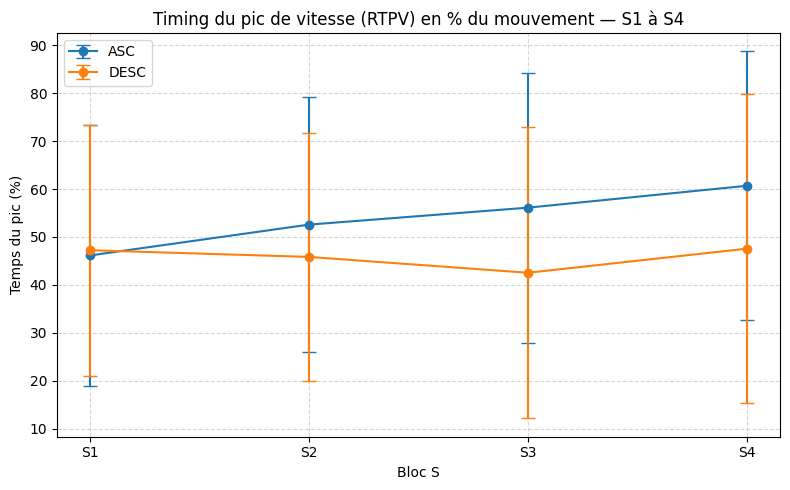

In [29]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

# ========================
# PARAMETRES
# ========================
n_points = 200  # nombre de points pour normaliser chaque mouvement
t_norm = np.linspace(0, 1, n_points)

time_vals = velocities["Time"].values

# ========================
# FONCTIONS UTILES
# ========================
def extract_S(col):
    """Extrait S1, S2, S3 ou S4 du nom de colonne en ignorant les préfixes"""
    m = re.search(r"_?(S[1-4])_", col)
    return m.group(1) if m else "UNKNOWN"

def extract_block(col):
    m = re.search(r"_(\d+)_Y$", col)
    return int(m.group(1)) if m else -1

def compute_peak_percent(curve):
    """Retourne l'indice du pic en pourcentage (0-100%) du mouvement."""
    peak_idx = np.argmax(np.abs(curve))
    return peak_idx / len(curve) * 100

# ========================
# COLONNES Y
# ========================
cols_Y = [c for c in velocities.columns if c.endswith("_Y")]

# ========================
# STOCKAGE PAR (S, bloc, phase)
# ========================
data_up = {}
data_down = {}

for col in cols_Y:
    if col not in minima_times_df.columns or col not in maxima_times_df.columns:
        continue

    S = extract_S(col)
    block = extract_block(col)
    if block == -1 or S=="UNKNOWN":
        continue
    key = (S, block)

    data_up.setdefault(key, [])
    data_down.setdefault(key, [])

    minima_times = minima_times_df[col].dropna().values
    maxima_times = maxima_times_df[col].dropna().values

    signal = velocities[col].values

    # ===== ASC (min → max) =====
    for t_min in minima_times:
        max_after = maxima_times[maxima_times > t_min]
        if len(max_after) == 0:
            continue
        t_max = max_after[0]

        mask = (time_vals >= t_min) & (time_vals <= t_max)
        seg_t = time_vals[mask]
        seg_y = signal[mask]
        if len(seg_t) < 10:
            continue

        # interpolation
        t_scaled = (seg_t - seg_t[0]) / (seg_t[-1] - seg_t[0])
        y_interp = np.interp(t_norm, t_scaled, seg_y)

        data_up[key].append(y_interp)

    # ===== DESC (max → min) =====
    for t_max in maxima_times:
        min_after = minima_times[minima_times > t_max]
        if len(min_after) == 0:
            continue
        t_min = min_after[0]

        mask = (time_vals >= t_max) & (time_vals <= t_min)
        seg_t = time_vals[mask]
        seg_y = signal[mask]
        if len(seg_t) < 10:
            continue

        t_scaled = (seg_t - seg_t[0]) / (seg_t[-1] - seg_t[0])
        y_interp = np.interp(t_norm, t_scaled, seg_y)

        data_down[key].append(y_interp)

# ========================
# CALCUL POURCENTAGE RTPV
# ========================
records = []

for key, curves in data_up.items():
    S, block = key
    if len(curves) == 0:
        continue

    for curve in curves:
        percent_peak = compute_peak_percent(curve)
        records.append({
            "S": S,
            "block": block,
            "phase": "ASC",
            "peak_percent": percent_peak
        })

for key, curves in data_down.items():
    S, block = key
    if len(curves) == 0:
        continue

    for curve in curves:
        percent_peak = compute_peak_percent(curve)
        records.append({
            "S": S,
            "block": block,
            "phase": "DESC",
            "peak_percent": percent_peak
        })

df_peak = pd.DataFrame(records)
df_peak = df_peak.sort_values(["S","block","phase"]).reset_index(drop=True)

print("✅ Timing du pic de vitesse en % du mouvement moyen :")
print(df_peak.head())

# ========================
# MOYENNE ET ECART-TYPE PAR S ET PHASE
# ========================
df_summary = df_peak.groupby(["S","phase"]).agg(
    mean_percent = ("peak_percent","mean"),
    std_percent = ("peak_percent","std"),
    n = ("peak_percent","count")
).reset_index()

print("\n✅ Résumé par S et phase :")
print(df_summary)

# ========================
# PLOT MOYENNE ± STD
# ========================
plt.figure(figsize=(8,5))
for phase in ["ASC","DESC"]:
    df_phase = df_summary[df_summary["phase"]==phase]
    plt.errorbar(
        df_phase["S"],
        df_phase["mean_percent"],
        yerr=df_phase["std_percent"],
        fmt='o-', capsize=5,
        label=phase
    )

plt.title("Timing du pic de vitesse (RTPV) en % du mouvement — S1 à S4")
plt.ylabel("Temps du pic (%)")
plt.xlabel("Bloc S")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

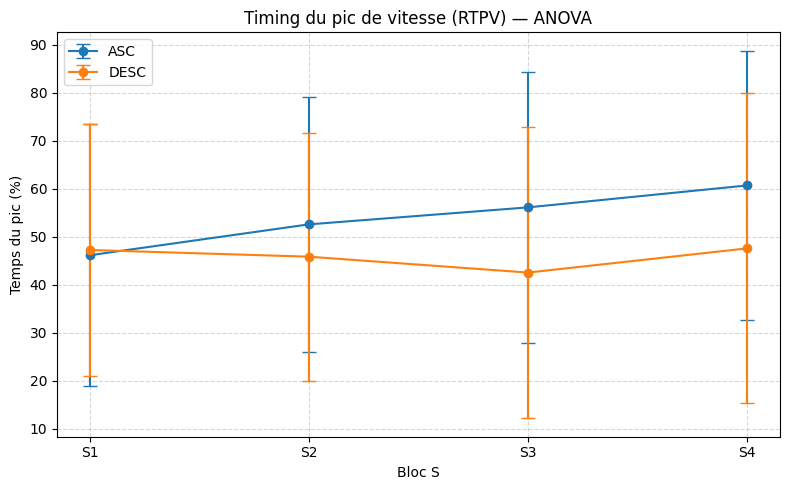

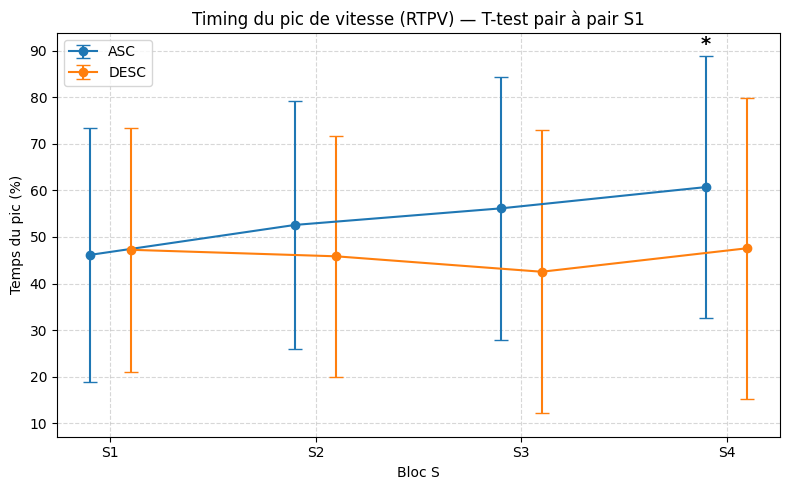

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ========================
# MOYENNE ET ECART-TYPE PAR S ET PHASE
# ========================
df_summary = df_peak.groupby(["S","phase"]).agg(
    mean_percent=("peak_percent","mean"),
    std_percent=("peak_percent","std"),
    n=("peak_percent","count")
).reset_index()

# ========================
# ANOVA
# ========================
anova_results = {}
for phase in ["ASC","DESC"]:
    df_phase = df_peak[df_peak["phase"]==phase]
    groups = [df_phase[df_phase["S"]==S]["peak_percent"].values for S in ["S1","S2","S3","S4"]]
    f_val, p_val = stats.f_oneway(*groups)
    anova_results[phase] = (f_val, p_val)

# ========================
# T-tests pair à pair S1
# ========================
ttest_results = {}
for phase in ["ASC","DESC"]:
    df_phase = df_peak[df_peak["phase"]==phase]
    S1_vals = df_phase[df_phase["S"]=="S1"]["peak_percent"].values
    ttest_results[phase] = {}
    for S in ["S2","S3","S4"]:
        S_vals = df_phase[df_phase["S"]==S]["peak_percent"].values
        t_stat, p_val = stats.ttest_ind(S1_vals, S_vals, equal_var=False)
        ttest_results[phase][S] = p_val

# ========================
# FONCTION POUR LES ETOILES
# ========================
def get_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return None

# ========================
# PLOT MOYENNE ± STD + ANOVA
# ========================
plt.figure(figsize=(8,5))
for phase in ["ASC","DESC"]:
    df_phase = df_summary[df_summary["phase"]==phase]
    plt.errorbar(
        df_phase["S"],
        df_phase["mean_percent"],
        yerr=df_phase["std_percent"],
        fmt='o-', capsize=5,
        label=phase
    )
    # étoiles ANOVA
    f_val, p_val = anova_results[phase]
    star = get_star(p_val)
    if star is not None:
        y_max = (df_phase["mean_percent"] + df_phase["std_percent"]).max()
        plt.ylim(top=y_max + 5)
        x_center = np.mean(range(len(df_phase)))
        plt.text(x_center, y_max + 0.5, star, ha='center', va='bottom', fontsize=16, fontweight='bold')

plt.title("Timing du pic de vitesse (RTPV) — ANOVA")
plt.ylabel("Temps du pic (%)")
plt.xlabel("Bloc S")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ========================
# PLOT T-TEST PAIR À PAIR S1
# ========================
plt.figure(figsize=(8,5))
width = 0.2
x_vals = np.arange(4)  # S1-S4 positions
labels = ["S1","S2","S3","S4"]

for i, phase in enumerate(["ASC","DESC"]):
    df_phase = df_summary[df_summary["phase"]==phase]
    plt.errorbar(
        x_vals + (i-0.5)*width,
        df_phase["mean_percent"],
        yerr=df_phase["std_percent"],
        fmt='o-', capsize=5,
        label=phase
    )
    # étoiles T-tests
    for j, S in enumerate(["S2","S3","S4"], start=1):
        p_val = ttest_results[phase][S]
        star = get_star(p_val)
        if star is not None:
            y = df_phase[df_phase["S"]==S]["mean_percent"].values[0] + df_phase[df_phase["S"]==S]["std_percent"].values[0]
            plt.ylim(top=max(df_summary["mean_percent"] + df_summary["std_percent"]) + 5, 
                     bottom = min(df_summary["mean_percent"] - df_summary["std_percent"]) - 5)
            plt.text(x_vals[j] + (i-0.5)*width, y + 0.5, star, ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.xticks(x_vals, labels)
plt.title("Timing du pic de vitesse (RTPV) — T-test pair à pair S1")
plt.ylabel("Temps du pic (%)")
plt.xlabel("Bloc S")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()